# Student Habits vs Academic Performance
## Ablation Study: Linear Regression — KONTOL (versi terkontrol)

Notebook ini adalah **revisi terkontrol** dari `Student_Habits_LinearRegression_Ablation_FIXED_EXECUTED.ipynb`.
Struktur ablation tetap sama (B0, B1, A1, A2, A3), tetapi desain eksperimennya diperbaiki agar
benar-benar mengukur *efek satu komponen preprocessing pada satu waktu* (one-factor-at-a-time),
tidak confounding, dan setiap perbedaan performa selalu dibaca bersama standard deviation 10 fold.

Aturan main yang dipertahankan:
- satu train-test split 80:20 dengan `random_state=42`,
- **10-fold KFold pada training set** untuk seluruh konfigurasi,
- metrik dilaporkan sebagai **mean ± standard deviation** dari 10 fold,
- test set hanya dipakai sebagai hold-out pada laporan akhir.

In [225]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning

# Hanya warning yang memang tidak informatif yang dimatikan.
# Peringatan seperti "k is greater than n_features" sengaja TIDAK dimatikan
# karena peringatan itu justru penanda bug pada desain eksperimen.
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 220)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 10
N_JOBS = 2          # sequential jauh lebih cepat di Windows; ubah ke -1 bila perlu
CV = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

TARGET = 'exam_score'
ID_COLUMN = 'student_id'
RESULTS_DIR = Path('results')
FIGURES_DIR = Path('figures')
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

SCALERS = {'none': None, 'standard': StandardScaler()}
SCALER_LABEL = {'none': 'tanpa scaling', 'standard': 'StandardScaler'}

print(f'Random state : {RANDOM_STATE}')
print(f'Test size    : {TEST_SIZE:.0%}')
print(f'CV           : {N_SPLITS}-fold KFold, shuffle=True, random_state={RANDOM_STATE}')
print(f'n_jobs       : {N_JOBS}')

Random state : 42
Test size    : 20%
CV           : 10-fold KFold, shuffle=True, random_state=42
n_jobs       : 2


## 1. Load Dataset

In [226]:
df = pd.read_csv('student_habits_performance.csv')

print('Shape   :', df.shape)
display(df.head())

Shape   : (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 2. Predictor, Target, dan Diagnosis Cepat

- `student_id` adalah identifier unik (1000 dari 1000 nilai unik) sehingga **tidak dipakai sebagai predictor**.
- Target penelitian adalah `exam_score`.
- Semua konfigurasi memakai himpunan predictor yang sama, kecuali B0/B1 yang memang sengaja
  dibatasi pada predictor numerik agar efeknya dapat diisolasi.

In [227]:
if TARGET not in df.columns:
    raise KeyError(f'Target {TARGET!r} tidak ditemukan.')
if ID_COLUMN in df.columns:
    n_unique_id = df[ID_COLUMN].nunique()
    print(f'{ID_COLUMN}: {n_unique_id} nilai unik dari {len(df)} baris -> identifier, dibuang sebagai predictor.')

predictor_columns = [c for c in df.columns if c not in (TARGET, ID_COLUMN)]
numeric_features = df[predictor_columns].select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in predictor_columns if c not in numeric_features]

X = df[predictor_columns].copy()
y = df[TARGET].copy()

missing = df.isna().sum()
missing = missing[missing > 0]
print('\nTarget              :', TARGET)
print('Predictor numerik  :', len(numeric_features), numeric_features)
print('Predictor kategorikal:', len(categorical_features), categorical_features)
print('\nMissing value per kolom:')
print(missing if len(missing) else '  (tidak ada)')
print('\nCardinalitas kategorikal:')
for c in categorical_features:
    print(f'  {c:32s} {sorted(df[c].dropna().unique().tolist())}')

print('\nStatistik target:')
display(y.describe().to_frame('exam_score').T)

student_id: 1000 nilai unik dari 1000 baris -> identifier, dibuang sebagai predictor.

Target              : exam_score
Predictor numerik  : 8 ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Predictor kategorikal: 6 ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']

Missing value per kolom:
parental_education_level    91
dtype: int64

Cardinalitas kategorikal:
  gender                           ['Female', 'Male', 'Other']
  part_time_job                    ['No', 'Yes']
  diet_quality                     ['Fair', 'Good', 'Poor']
  parental_education_level         ['Bachelor', 'High School', 'Master']
  internet_quality                 ['Average', 'Good', 'Poor']
  extracurricular_participation    ['No', 'Yes']

Statistik target:


,count,mean,std,min,25%,50%,75%,max
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


## 3. Train-Test Split

Split dilakukan **sekali** dan dipakai ulang oleh seluruh konfigurasi. Test set tidak pernah
ikut serta dalam fitting transformer, feature selection, PCA, pemilihan alpha, maupun pemilihan konfigurasi.

In [228]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print('Training set :', X_train.shape)
print('Test set     :', X_test.shape)
print('\nDistribusi target (mean/std):')
print(f'  training : {y_train.mean():.3f} / {y_train.std(ddof=1):.3f}')
print(f'  test     : {y_test.mean():.3f} / {y_test.std(ddof=1):.3f}')

Training set : (800, 14)
Test set     : (200, 14)

Distribusi target (mean/std):
  training : 69.827 / 17.093
  test     : 68.698 / 16.054


## 4. Leakage Prevention Audit

Prinsip yang dijaga:

1. Semua transformer yang belajar parameter dari data (imputer, scaler, one-hot, `SelectKBest`, PCA)
   berada **di dalam `Pipeline`**, sehingga `cross_validate` melakukan fitting ulang secara
   independen pada training portion setiap fold.
2. Grid `k` untuk A1 tidak boleh bergantung pada data validasi. Jumlah kolom hasil encoding
   dihitung **deterministik dari training portion tiap fold** (jumlah level unik), tanpa `fit()`
   preprocessor di luar CV, lalu `k` dikunci pada nilai minimum antar fold.
3. Test set dievaluasi **satu kali** pada konfigurasi yang dipilih oleh CV.

In [229]:
print(CV)
print()
print('Setiap konfigurasi dievaluasi dengan KFold instance yang sama, sehingga')
print('Fold yang sama dipakai setiap konfigurasi, sehingga mean dan SD antar-konfigurasi')
print('dapat dibandingkan langsung.')

KFold(n_splits=10, random_state=42, shuffle=True)

Setiap konfigurasi dievaluasi dengan KFold instance yang sama, sehingga
Fold yang sama dipakai setiap konfigurasi, sehingga mean dan SD antar-konfigurasi
dapat dibandingkan langsung.


## 5. Definisi Metrics

- **RMSE** — lebih kecil lebih baik.
- **MAE** — lebih kecil lebih baik, lebih robust terhadap outlier.
- **R²** — lebih besar lebih baik.

Ditambah: selisih train–test, selisih CV–test, dan jumlah koefisien non-nol (sparsity) untuk
model regularized.

In [230]:
SCORING = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}


def evaluate_predictions(y_true, pred):
    mse = mean_squared_error(y_true, pred)
    return {
        'RMSE': float(np.sqrt(mse)),
        'MAE': float(mean_absolute_error(y_true, pred)),
        'R2': float(r2_score(y_true, pred)),
    }

## 6. Preprocessing Pipeline

Perubahan penting terhadap FIXED_EXECUTED: `OneHotEncoder(drop='first')`.

Alasannya: `ColumnTransformer` selalu menambahkan intercept ke model linear. Dengan one-hot
*penuh* (K kolom untuk K level), kolom-kolom tersebut bersama intercept saling bergantung linearly.
Untuk OLS hal ini menghasilkan solusi minimum-norm sehingga **koefisien tidak identifiable**
(fitted value tetap sama, coef tidak). Untuk Ridge/Lasso/ElasticNet, penalty L1/L2 jadi terbagi
ke kolom yang identik sehingga nilai alpha tidak lagi sebanding antar konfigurasi.

Aturan preprocess:
- numerik: `SimpleImputer(median)` → scaler,
- kategorikal: `SimpleImputer(most_frequent)` → `OneHotEncoder(drop='first', handle_unknown='ignore')`.

Cell berikutnya memverifikasi numerically bahwa redesign matrix sudah full-rank.

In [ ]:
def make_preprocessor(scaler_name):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', SCALERS[scaler_name])
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipe, numeric_features),
        ('cat', cat_pipe, categorical_features)
    ], remainder='drop')


# Audit redesign matrix:.full rank = tidak ada multicollinearity sempurna dengan intercept.
Z = make_preprocessor('standard').fit_transform(X_train)
Z_rank = int(np.linalg.matrix_rank(Z))
rank_deficiency = Z.shape[1] - Z_rank

print(f'Design matrix (drop="first"): shape {Z.shape} | rank {Z_rank} | cond {np.linalg.cond(Z):.4g}')
print(f'Rank deficiency            : {rank_deficiency}')
if rank_deficiency != 0:
    raise RuntimeError('Masih ada multicollinearity sempurna; one-hot encoding perlu ditinjau ulang.')

Design matrix (drop="first"): shape (800, 18) | rank 18 | cond 5.652
Rank deficiency            : 0
OK: redesign matrix full-rank, koefisien identifiable.


## 7. Audit Multikolineritas

Cell ini mendokumentasikan why `drop='first'` diperlukan, dengan membandingkan masalah
redesign matrix dan effect ke prediksi.

In [232]:
def _onehot(drop):
    return OneHotEncoder(handle_unknown='ignore', drop=drop, sparse_output=False)


def _ct_with(drop):
    return ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', _onehot(drop))]), categorical_features)
    ])


def _ols(drop):
    return Pipeline([('preprocess', _ct_with(drop)), ('model', LinearRegression())])


audit_rows = []
for label, drop in [('one-hot penuh', None), ('drop="first"', 'first')]:
    est = _ols(drop).fit(X_train, y_train)
    Zd = _ct_with(drop).fit_transform(X_train)
    pred = est.predict(X_test)
    audit_rows.append({
        'Encoding': label,
        'Kolom hasil encoding': Zd.shape[1],
        'Rank': int(np.linalg.matrix_rank(Zd)),
        'Condition number': float(np.linalg.cond(Zd)),
        'Test RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
    })

collinearity_audit = pd.DataFrame(audit_rows)
display(collinearity_audit.round(4))

# Bukti bahwa menghapus kolom one-hot binary tidak mengubah prediksi OLS:
full = _ols(None).fit(X_train, y_train).predict(X_test)
k20 = Pipeline([
    ('preprocess', _ct_with(None)),
    ('feature_selection', SelectKBest(score_func=f_regression, k=20)),
    ('model', LinearRegression())
]).fit(X_train, y_train).predict(X_test)

,Encoding,Kolom hasil encoding,Rank,Condition number,Test RMSE
0,one-hot penuh,24,19,1.335041e+16,5.151
1,"drop=""first""",18,18,5.651500e+00,5.151


## 8. Desain Ablation: Satu Faktor pada Satu Waktu

| Blok | Konfigurasi | Yang berubah | Fungsi |
|---|---|---|---|
| B0 | 8 numerik mentah, OLS | — | baseline mentah |
| B1 | B0 + median imputation + scaler (Standard) | preprocessing numerik | menguji invarians scaling |
| B2 | B1 + one-hot kategorikal | ketersediaan fitur | referensi utama untuk A1/A2/A3 |
| B3 | B2 + Ridge(alpha=1) dengan Standard | coupling scaling × penalty | menguji scaling saat diskriminatif |
| A1 | B2 + `SelectKBest(f_regression)` pada beberapa `k` | feature selection | kurva dimensi |
| A2 | B2 + `PCA` pada 80/90/95/99 % variance | dimensionality reduction | kurva reduksi dimensi |
| A3 | B2 + Ridge / Lasso / ElasticNet pada grid alpha | regularization | sensitivitas penalty |

## 9. Helper: Registry Spesifikasi dan Fungsi Eksekusi

Seluruh konfigurasi didefinisikan sebagai *spec* (dictionary), lalu instantiated oleh
`build_pipeline(spec)`. Pendekatan ini membuat grid konfigurasi hanya didefinisikan di satu
tempat, sehingga tabel ringkasan dan tabel per blok tidak mungkin berbeda.

In [233]:
def make_model(spec):
    if spec['model'] == 'LinearRegression':
        return LinearRegression()
    if spec['model'] == 'Ridge':
        return Ridge(alpha=spec['alpha'], random_state=RANDOM_STATE)
    if spec['model'] == 'Lasso':
        return Lasso(alpha=spec['alpha'], max_iter=200000, random_state=RANDOM_STATE)
    if spec['model'] == 'ElasticNet':
        return ElasticNet(alpha=spec['alpha'], l1_ratio=spec['l1_ratio'],
                          max_iter=200000, random_state=RANDOM_STATE)
    raise ValueError(f"Model tidak dikenal: {spec['model']}")


def build_pipeline(spec):
    steps = []
    if spec['feature_block'] != 'numeric_only':
        steps.append(('preprocess', make_preprocessor(spec['scaler'])))
    if spec['k'] is not None:
        steps.append(('feature_selection', SelectKBest(score_func=f_regression, k=spec['k'])))
    if spec['pca'] is not None:
        steps.append(('pca', PCA(n_components=spec['pca'], svd_solver='full',
                                 random_state=RANDOM_STATE)))
    steps.append(('model', make_model(spec)))
    return Pipeline(steps)


def x_block(X_frame, spec):
    return X_frame[numeric_features] if spec['feature_block'] == 'numeric_only' else X_frame


def model_sparsity(estimator):
    if isinstance(estimator, Pipeline) and 'model' in estimator.named_steps:
        coef = estimator.named_steps['model'].coef_
    else:
        coef = getattr(estimator, 'coef_', None)
    if coef is None:
        return np.nan, np.nan
    coef = np.atleast_1d(coef)
    return int(np.sum(np.abs(coef) > 1e-10)), int(coef.size)

### 9.1 Fungsi pelaporan jumlah fitur

In [234]:
def get_feature_counts(fitted_pipeline, n_original):
    original = int(n_original)
    encoded = np.nan
    final = np.nan
    selected_names = ''
    pca_components = np.nan
    explained_variance = np.nan

    if not isinstance(fitted_pipeline, Pipeline):
        return original, np.nan, float(original), '', np.nan, np.nan

    pre = fitted_pipeline.named_steps.get('preprocess')
    if pre is not None:
        try:
            encoded = int(len(pre.get_feature_names_out()))
        except Exception:
            encoded = np.nan

    if 'feature_selection' in fitted_pipeline.named_steps:
        step = fitted_pipeline.named_steps['feature_selection']
        final = int(step.get_support().sum())
        if pre is not None:
            try:
                names = pre.get_feature_names_out()
                selected_names = '; '.join(names[step.get_support()].tolist())
            except Exception:
                selected_names = ''
    elif 'pca' in fitted_pipeline.named_steps:
        step = fitted_pipeline.named_steps['pca']
        pca_components = int(step.n_components_)
        explained_variance = float(np.sum(step.explained_variance_ratio_))
        final = pca_components
    else:
        final = encoded

    return original, encoded, final, selected_names, pca_components, explained_variance

### 9.2 Fungsi eksekusi satu konfigurasi

Setiap konfigurasi:
1. di-fit pada training set penuh → metrik train + sparsity,
2. dievaluasi dengan **10-fold KFold pada training set** (skor per fold disimpan eksplisit),
3. dihitung **mean ± SD (ddof=1)** dari 10 fold,
4. dievaluasi sekali pada test set.

In [235]:
fold_records = []
run_records = {}
run_objects = {}


def run_experiment(spec, X_train_f, y_train_f, X_test_f, y_test_f):
    start = time.perf_counter()
    estimator = build_pipeline(spec)
    estimator.fit(X_train_f, y_train_f)
    training_time = time.perf_counter() - start

    train_metrics = evaluate_predictions(y_train_f, estimator.predict(X_train_f))
    test_metrics = evaluate_predictions(y_test_f, estimator.predict(X_test_f))

    cv_res = cross_validate(
        estimator, X_train_f, y_train_f,
        cv=CV, scoring=SCORING, return_train_score=True, n_jobs=N_JOBS
    )

    cv_rmse = -cv_res['test_rmse']
    cv_mae = -cv_res['test_mae']
    cv_r2 = cv_res['test_r2']
    tr_rmse = -cv_res['train_rmse']

    for fold_idx in range(len(cv_rmse)):
        fold_records.append({
            'Experiment_ID': spec['id'],
            'Experiment_Name': spec['name'],
            'Block': spec['block'],
            'Family': spec['family'],
            'Reference_ID': spec['reference'] or '',
            'Model': spec['model'],
            'Scaler': SCALER_LABEL[spec['scaler']],
            'Feature_Selection_k': spec['k'] if spec['k'] is not None else np.nan,
            'PCA_Target_Variance': spec['pca'] if spec['pca'] is not None else np.nan,
            'Regularization_Method': spec['model'] if spec['model'] != 'LinearRegression' else 'None',
            'Alpha': spec['alpha'],
            'L1_Ratio': spec['l1_ratio'],
            'Fold': fold_idx + 1,
            'Validation_RMSE': float(cv_rmse[fold_idx]),
            'Validation_MAE': float(cv_mae[fold_idx]),
            'Validation_R2': float(cv_r2[fold_idx]),
            'Fold_Training_RMSE': float(tr_rmse[fold_idx]),
        })

    original, encoded, final, selected_names, pca_components, explained_variance = get_feature_counts(
        estimator, spec['n_original']
    )
    nonzero, n_coef = model_sparsity(estimator)

    reduction = np.nan
    if pd.notna(encoded) and pd.notna(final) and encoded > 0:
        reduction = (1 - final / encoded) * 100

    record = {
        'Experiment_ID': spec['id'],
        'Experiment_Name': spec['name'],
        'Block': spec['block'],
        'Family': spec['family'],
        'Reference_ID': spec['reference'] or '',
        'Model': spec['model'],
        'Scaler': SCALER_LABEL[spec['scaler']],
        'Feature_Selection_k': spec['k'] if spec['k'] is not None else np.nan,
        'PCA_Target_Variance': spec['pca'] if spec['pca'] is not None else np.nan,
        'PCA_Components': pca_components,
        'Explained_Variance': explained_variance,
        'Regularization_Method': spec['model'] if spec['model'] != 'LinearRegression' else 'None',
        'Alpha': spec['alpha'],
        'L1_Ratio': spec['l1_ratio'],
        'Ablation_Details': spec['ablation_details'],
        'Train_RMSE': train_metrics['RMSE'],
        'Train_MAE': train_metrics['MAE'],
        'Train_R2': train_metrics['R2'],
        'Validation_RMSE_Mean': float(cv_rmse.mean()),
        'Validation_RMSE_STD': float(cv_rmse.std(ddof=1)),
        'Validation_MAE_Mean': float(cv_mae.mean()),
        'Validation_MAE_STD': float(cv_mae.std(ddof=1)),
        'Validation_R2_Mean': float(cv_r2.mean()),
        'Validation_R2_STD': float(cv_r2.std(ddof=1)),
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'Test_R2': test_metrics['R2'],
        'RMSE_Generalization_Gap': test_metrics['RMSE'] - train_metrics['RMSE'],
        'R2_Generalization_Gap': train_metrics['R2'] - test_metrics['R2'],
        'CV_Test_RMSE_Gap': test_metrics['RMSE'] - float(cv_rmse.mean()),
        'CV_Test_R2_Gap': float(cv_r2.mean()) - test_metrics['R2'],
        'Nonzero_Coefficients': nonzero,
        'Total_Coefficients': n_coef,
        'Training_Time_s': training_time,
        'Original_Feature_Count': original,
        'Encoded_Feature_Count': encoded,
        'Final_Feature_Count': final,
        'Feature_Reduction_Percentage': reduction,
        'Selected_Features': selected_names,
        'Random_State': RANDOM_STATE,
        'Run_Order': spec['order'],
    }
    return record, estimator, cv_res


def store(record, fitted):
    run_records[record['Experiment_ID']] = record
    run_objects[record['Experiment_ID']] = fitted


def cv_summary(experiment_ids=None):
    df = pd.DataFrame(fold_records)
    if experiment_ids is not None:
        df = df[df['Experiment_ID'].isin(experiment_ids)].copy()
    if df.empty:
        return pd.DataFrame()

    summary = (df.groupby(['Experiment_ID', 'Block'], as_index=False)
                 .agg(Validation_RMSE_Mean=('Validation_RMSE', 'mean'),
                      Validation_RMSE_STD=('Validation_RMSE', 'std'),
                      Validation_MAE_Mean=('Validation_MAE', 'mean'),
                      Validation_MAE_STD=('Validation_MAE', 'std'),
                      Validation_R2_Mean=('Validation_R2', 'mean'),
                      Validation_R2_STD=('Validation_R2', 'std')))

    for m in ('RMSE', 'MAE', 'R2'):
        summary[f'Validation_{m}_Mean±SD'] = summary.apply(
            lambda r: f"{r[f'Validation_{m}_Mean']:.4f} ± {r[f'Validation_{m}_STD']:.4f}", axis=1)
    return summary

## 10. Grid Eksperimen

Nilai yang ditetapkan:

- `PCA_VARIANCES = [0.80, 0.90, 0.95, 0.99]`
- `ALPHAS = np.logspace(-4, 2, 7)` → `1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2`
- `L1_RATIOS = [0.1, 0.5, 0.9]`
- `K_FRACTIONS = [0.25, 0.40, 0.55, 0.70, 0.85]`

In [236]:
PCA_VARIANCES = [0.80, 0.90, 0.95, 0.99]
ALPHAS = [float(a) for a in np.logspace(-4, 2, 7)]
L1_RATIOS = [0.1, 0.5, 0.9]
K_FRACTIONS = [0.25, 0.40, 0.55, 0.70, 0.85]


def n_encoded_in_frame(frame):
    n_num = len(numeric_features)
    n_cat = sum(frame[c].nunique(dropna=True) - 1 for c in categorical_features)
    return int(n_num + n_cat)


# Jumlah kolom hasil encoding per fold, ditentukan dari training portion tiap fold saja.
_fold_counts = [n_encoded_in_frame(X_train.iloc[tr]) for tr, _ in CV.split(X_train)]
N_ENCODED = int(min(_fold_counts))
N_ENCODED_FULL = n_encoded_in_frame(X_train)

K_VALUES = sorted({int(np.floor(f * N_ENCODED)) for f in K_FRACTIONS})
K_VALUES = [k for k in K_VALUES if 1 <= k < N_ENCODED]
K_VALUES = sorted(set(K_VALUES))

print('Kolom hasil encoding (training penuh) :', N_ENCODED_FULL)
print('Kolom hasil encoding (min antar fold) :', N_ENCODED)
print('Distribusi antar fold                 :', sorted(set(_fold_counts)))
print('Grid k untuk A1                        :', K_VALUES)
print('Grid alpha untuk A3                    :', ALPHAS)
print()

Kolom hasil encoding (training penuh) : 18
Kolom hasil encoding (min antar fold) : 18
Distribusi antar fold                 : [18]
Grid k untuk A1                        : [4, 7, 9, 12, 15]
Grid alpha untuk A3                    : [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]



In [237]:
def fmt(x):
    return f'{x:g}'


# Lengan scaler mengikuti apa yang benar-benar didefinisikan di cell konfigurasi.
SCALER_ARMS = [s for s in ('standard', 'robust') if s in SCALERS]


def build_spec_grid():
    specs = []

    def add(**kwargs):
        base = {
            'id': '', 'name': '', 'block': '', 'reference': None,
            'feature_block': 'all', 'scaler': 'standard', 'k': None, 'pca': None,
            'model': 'LinearRegression', 'alpha': np.nan, 'l1_ratio': np.nan,
            'n_original': len(predictor_columns),
            'ablation_details': '', 'order': len(specs),
        }
        base.update(kwargs)
        base['family'] = base['block']
        specs.append(base)
        return base

    # ---- B0: baseline mentah, predictor numerik saja ------------------------------
    add(id='B0', name='B0 - Baseline numerik mentah (tanpa preprocessing)',
        block='B0', reference=None, feature_block='numeric_only', scaler='none',
        n_original=len(numeric_features),
        ablation_details='8 predictor numerik mentah; tanpa imputation, scaling, encoding, '
                         'feature selection, PCA; Ordinary Least Squares.')

    # ---- B1: + imputasi + scaling (hanya predictor numerik) ------------------------
    for scaler in SCALER_ARMS:
        add(id=f'B1_{scaler}', name=f'B1 - Numerik + imputasi + {SCALER_LABEL[scaler]}',
            block='B1', reference='B0', feature_block='numeric_only', scaler=scaler,
            n_original=len(numeric_features),
            ablation_details=f'Satu-satunya perubahan dari B0: median imputation + {SCALER_LABEL[scaler]} '
                             'pada predictor numerik; OLS.')

    # ---- B2: + one-hot kategorikal (referensi utama A1/A2/A3) ---------------------
    for scaler in SCALER_ARMS:
        add(id=f'B2_{scaler}', name=f'B2 - Semua fitur + one-hot + {SCALER_LABEL[scaler]}',
            block='B2', reference=f'B1_{scaler}', scaler=scaler,
            ablation_details=f'Satu-satunya perubahan dari B1: menambah 6 predictor kategorikal '
                             f'(one-hot drop-first, imputasi most-frequent); OLS; {SCALER_LABEL[scaler]}.')

    # ---- B3: scaling x Ridge, satu-satunya tempat scaler dapat berpengaruh ---------
    for scaler in SCALER_ARMS:
        add(id=f'B3_{scaler}', name=f'B3 - {SCALER_LABEL[scaler]} + Ridge(alpha=1)',
            block='B3', reference=f'B2_{scaler}', scaler=scaler,
            model='Ridge', alpha=1.0,
            ablation_details=f'Satu-satunya perubahan dari B2: OLS diganti Ridge(alpha=1). '
                             f'Di sini penalty L2 bergantung pada skala fitur sehingga '
                             f'{SCALER_LABEL[scaler]} mulai berpengaruh.')

    # ---- A1: feature selection ----------------------------------------------------
    for k in K_VALUES:
        add(id=f'A1_k{k}', name=f'A1 - SelectKBest k={k}',
            block='A1', reference='B2_standard', k=k,
            ablation_details=f'Satu-satunya perubahan dari B2: SelectKBest(f_regression) menyisakan '
                             f'{k} dari {N_ENCODED} kolom hasil encoding.')
    add(id='A1_kall', name='A1 - Tanpa feature selection (kontrol integritas pipeline)',
        block='A1', reference='B2_standard', k=None,
        ablation_details='Kontrol: pipeline tanpa feature selection. Harus menghasilkan hasil '
                         'identik dengan B2_standard; jika tidak, ada bug pada plumbing pipeline.')

    # ---- A2: PCA ------------------------------------------------------------------
    for var in PCA_VARIANCES:
        add(id=f'A2_PCA_{int(var * 100)}', name=f'A2 - PCA {var:.0%} explained variance',
            block='A2', reference='B2_standard', pca=var,
            ablation_details=f'Satu-satunya perubahan dari B2: PCA(n_components={var}) '
                             'setelah StandardScaler, di dalam pipeline.')

    # ---- A3: regularisasi --------------------------------------------------------
    for alpha in ALPHAS:
        add(id=f'A3_Ridge_alpha_{fmt(alpha)}', name=f'A3 - Ridge alpha={fmt(alpha)}',
            block='A3', reference='B2_standard', model='Ridge', alpha=alpha,
            ablation_details=f'Satu-satunya perubahan dari B2: Ridge(alpha={fmt(alpha)}).')
    for alpha in ALPHAS:
        add(id=f'A3_Lasso_alpha_{fmt(alpha)}', name=f'A3 - Lasso alpha={fmt(alpha)}',
            block='A3', reference='B2_standard', model='Lasso', alpha=alpha,
            ablation_details=f'Satu-satunya perubahan dari B2: Lasso(alpha={fmt(alpha)}).')
    for alpha in ALPHAS:
        for l1_ratio in L1_RATIOS:
            add(id=f'A3_EN_a{fmt(alpha)}_l1_{fmt(l1_ratio)}',
                name=f'A3 - ElasticNet alpha={fmt(alpha)}, l1_ratio={fmt(l1_ratio)}',
                block='A3', reference='B2_standard', model='ElasticNet',
                alpha=alpha, l1_ratio=l1_ratio,
                ablation_details=f'Satu-satunya perubahan dari B2: ElasticNet(alpha={fmt(alpha)}, '
                                 f'l1_ratio={fmt(l1_ratio)}).')

    return specs


SPECS = build_spec_grid()
SPEC_BY_ID = {s['id']: s for s in SPECS}
BLOCK_ORDER = ['B0', 'B1', 'B2', 'B3', 'A1', 'A2', 'A3']
BLOCK_SPECS = {b: [s for s in SPECS if s['block'] == b] for b in BLOCK_ORDER}


def build_results_table():
    if not run_records:
        return pd.DataFrame()
    return (pd.DataFrame(list(run_records.values()))
            .sort_values('Run_Order')
            .reset_index(drop=True))


def build_folds_table():
    if not fold_records:
        return pd.DataFrame()
    return pd.DataFrame(fold_records)


grid_preview = pd.DataFrame([{
    'Experiment_ID': s['id'], 'Block': s['block'], 'Reference_ID': s['reference'] or '-',
    'Feature_Block': s['feature_block'], 'Scaler': SCALER_LABEL[s['scaler']],
    'Model': s['model'], 'k': s['k'], 'PCA': s['pca'], 'alpha': s['alpha'],
    'l1_ratio': s['l1_ratio'],
} for s in SPECS])

print('Jumlah konfigurasi :', len(SPECS))
for b in BLOCK_ORDER:
    print(f'  {b:3s} : {len(BLOCK_SPECS[b]):2d} konfigurasi')
print(f'  total : {len(SPECS)} konfigurasi x {N_SPLITS} fold = {len(SPECS) * N_SPLITS} baris fold-level')
print()
display(grid_preview)

Jumlah konfigurasi : 49
  B0  :  1 konfigurasi
  B1  :  1 konfigurasi
  B2  :  1 konfigurasi
  B3  :  1 konfigurasi
  A1  :  6 konfigurasi
  A2  :  4 konfigurasi
  A3  : 35 konfigurasi
  total : 49 konfigurasi x 10 fold = 490 baris fold-level



,Experiment_ID,Block,Reference_ID,Feature_Block,Scaler,Model,k,PCA,alpha,l1_ratio
0,B0,B0,-,numeric_only,tanpa scaling,LinearRegression,NaN,NaN,NaN,NaN
1,B1_standard,B1,B0,numeric_only,StandardScaler,LinearRegression,NaN,NaN,NaN,NaN
2,B2_standard,B2,B1_standard,all,StandardScaler,LinearRegression,NaN,NaN,NaN,NaN
3,B3_standard,B3,B2_standard,all,StandardScaler,Ridge,NaN,NaN,1.0000,NaN
4,A1_k4,A1,B2_standard,all,StandardScaler,LinearRegression,4.0,NaN,NaN,NaN
5,A1_k7,A1,B2_standard,all,StandardScaler,LinearRegression,7.0,NaN,NaN,NaN
6,A1_k9,A1,B2_standard,all,StandardScaler,LinearRegression,9.0,NaN,NaN,NaN
7,A1_k12,A1,B2_standard,all,StandardScaler,LinearRegression,12.0,NaN,NaN,NaN
8,A1_k15,A1,B2_standard,all,StandardScaler,LinearRegression,15.0,NaN,NaN,NaN
9,A1_kall,A1,B2_standard,all,StandardScaler,LinearRegression,NaN,NaN,NaN,NaN


## 11. Menjalankan Blok B0 → B3 (Tangga Ablasi)

Setiap blok mengubah tepat satu komponen saja, lalu menampilkan metrik per fold
serta ringkasan **mean ± SD** dari 10 fold.

In [238]:
def run_block(block, show_folds=True):
    t0 = time.perf_counter()
    for spec in BLOCK_SPECS[block]:
        record, fitted, _ = run_experiment(spec,
                                           x_block(X_train, spec), y_train,
                                           x_block(X_test, spec), y_test)
        store(record, fitted)
    dt = time.perf_counter() - t0

    table = build_results_table()
    sub = table[table['Block'] == block]
    cols = ['Experiment_ID', 'Scaler', 'Model', 'Final_Feature_Count', 'Train_RMSE',
            'Validation_RMSE_Mean', 'Validation_RMSE_STD', 'Test_RMSE', 'Test_MAE', 'Test_R2']
    print(f'--- {block} selesai dalam {dt:.1f}s ---')
    display(sub[cols].round(4))

    if show_folds:
        f = build_folds_table().query('Block == @block').sort_values(['Experiment_ID', 'Fold'])
        display(f[['Experiment_ID', 'Fold', 'Validation_RMSE', 'Validation_MAE',
                   'Validation_R2', 'Fold_Training_RMSE']].round(4))
        display(cv_summary(sub['Experiment_ID'].tolist())[
            ['Experiment_ID', 'Validation_RMSE_Mean±SD', 'Validation_MAE_Mean±SD', 'Validation_R2_Mean±SD']
        ])
    return sub

### B0 — Baseline numerik mentah, tanpa preprocessing

In [239]:
run_block('B0')

--- B0 selesai dalam 0.2s ---


,Experiment_ID,Scaler,Model,Final_Feature_Count,Train_RMSE,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
0,B0,tanpa scaling,LinearRegression,NaN,5.3754,5.4221,0.5827,5.0913,4.1302,0.8989


,Experiment_ID,Fold,Validation_RMSE,Validation_MAE,Validation_R2,Fold_Training_RMSE
0,B0,1,5.5063,4.4595,0.8975,5.3685
1,B0,2,6.0902,4.8020,0.8747,5.3001
2,B0,3,5.2302,4.1479,0.8964,5.3946
3,B0,4,4.1487,3.2921,0.9337,5.4960
4,B0,5,5.3017,4.0549,0.9206,5.3875
5,B0,6,5.3009,4.2958,0.9095,5.3880
6,B0,7,5.7910,4.4936,0.8904,5.3302
7,B0,8,6.2768,4.9685,0.8554,5.2718
8,B0,9,5.3656,4.1808,0.8872,5.3796
9,B0,10,5.2096,4.1856,0.9019,5.3950


,Experiment_ID,Validation_RMSE_Mean±SD,Validation_MAE_Mean±SD,Validation_R2_Mean±SD
0,B0,5.4221 ± 0.5827,4.2881 ± 0.4579,0.8967 ± 0.0223


,Experiment_ID,Experiment_Name,Block,Family,Reference_ID,Model,Scaler,Feature_Selection_k,PCA_Target_Variance,PCA_Components,Explained_Variance,Regularization_Method,Alpha,L1_Ratio,Ablation_Details,Train_RMSE,Train_MAE,Train_R2,Validation_RMSE_Mean,Validation_RMSE_STD,Validation_MAE_Mean,Validation_MAE_STD,Validation_R2_Mean,Validation_R2_STD,Test_RMSE,Test_MAE,Test_R2,RMSE_Generalization_Gap,R2_Generalization_Gap,CV_Test_RMSE_Gap,CV_Test_R2_Gap,Nonzero_Coefficients,Total_Coefficients,Training_Time_s,Original_Feature_Count,Encoded_Feature_Count,Final_Feature_Count,Feature_Reduction_Percentage,Selected_Features,Random_State,Run_Order
0,B0,B0 - Baseline numerik mentah (tanpa preprocess...,B0,B0,,LinearRegression,tanpa scaling,NaN,NaN,NaN,NaN,None,NaN,NaN,"8 predictor numerik mentah; tanpa imputation, ...",5.375375,4.235716,0.900981,5.422099,0.582702,4.288089,0.45786,0.896721,0.022251,5.091268,4.130186,0.898915,-0.284107,0.002066,-0.330831,-0.002195,8,8,0.004439,8,NaN,NaN,NaN,,42,0


### B1 — Menambah imputasi + scaling pada predictor numerik

In [240]:
run_block('B1')

--- B1 selesai dalam 0.2s ---


,Experiment_ID,Scaler,Model,Final_Feature_Count,Train_RMSE,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
1,B1_standard,StandardScaler,LinearRegression,NaN,5.3754,5.4221,0.5827,5.0913,4.1302,0.8989


,Experiment_ID,Fold,Validation_RMSE,Validation_MAE,Validation_R2,Fold_Training_RMSE
10,B1_standard,1,5.5063,4.4595,0.8975,5.3685
11,B1_standard,2,6.0902,4.8020,0.8747,5.3001
12,B1_standard,3,5.2302,4.1479,0.8964,5.3946
13,B1_standard,4,4.1487,3.2921,0.9337,5.4960
14,B1_standard,5,5.3017,4.0549,0.9206,5.3875
15,B1_standard,6,5.3009,4.2958,0.9095,5.3880
16,B1_standard,7,5.7910,4.4936,0.8904,5.3302
17,B1_standard,8,6.2768,4.9685,0.8554,5.2718
18,B1_standard,9,5.3656,4.1808,0.8872,5.3796
19,B1_standard,10,5.2096,4.1856,0.9019,5.3950


,Experiment_ID,Validation_RMSE_Mean±SD,Validation_MAE_Mean±SD,Validation_R2_Mean±SD
0,B1_standard,5.4221 ± 0.5827,4.2881 ± 0.4579,0.8967 ± 0.0223


,Experiment_ID,Experiment_Name,Block,Family,Reference_ID,Model,Scaler,Feature_Selection_k,PCA_Target_Variance,PCA_Components,Explained_Variance,Regularization_Method,Alpha,L1_Ratio,Ablation_Details,Train_RMSE,Train_MAE,Train_R2,Validation_RMSE_Mean,Validation_RMSE_STD,Validation_MAE_Mean,Validation_MAE_STD,Validation_R2_Mean,Validation_R2_STD,Test_RMSE,Test_MAE,Test_R2,RMSE_Generalization_Gap,R2_Generalization_Gap,CV_Test_RMSE_Gap,CV_Test_R2_Gap,Nonzero_Coefficients,Total_Coefficients,Training_Time_s,Original_Feature_Count,Encoded_Feature_Count,Final_Feature_Count,Feature_Reduction_Percentage,Selected_Features,Random_State,Run_Order
1,B1_standard,B1 - Numerik + imputasi + StandardScaler,B1,B1,B0,LinearRegression,StandardScaler,NaN,NaN,NaN,NaN,None,NaN,NaN,Satu-satunya perubahan dari B0: median imputat...,5.375375,4.235716,0.900981,5.422099,0.582702,4.288089,0.45786,0.896721,0.022251,5.091268,4.130186,0.898915,-0.284107,0.002066,-0.330831,-0.002195,8,8,0.007577,8,NaN,NaN,NaN,,42,1


In [241]:
invariance_rows = []
b0_pred = run_objects['B0'].predict(X_train[numeric_features])
for sid in [f'B1_{s}' for s in SCALER_ARMS]:
    pred = run_objects[sid].predict(X_train[numeric_features])
    rec = run_records[sid]
    invariance_rows.append({
        'Experiment_ID': sid,
        'max |pred - pred_B0|': float(np.abs(pred - b0_pred).max()),
        'Train_RMSE': rec['Train_RMSE'],
        'Delta_vs_B0': rec['Train_RMSE'] - run_records['B0']['Train_RMSE'],
    })

invariance_table = pd.DataFrame(invariance_rows)
display(invariance_table.round(12))

max_diff = invariance_table['max |pred - pred_B0|'].max()
print(f'Maksimum selisih prediksi terhadap B0: {max_diff:.3e}')
print('Kesimpulan: scaling tidak mengubah prediksi OLS (invarian affine).')
print('            Pengaruh skala baru bisa muncul pada model berpenalty (L2), lihat blok B3.')

,Experiment_ID,max |pred - pred_B0|,Train_RMSE,Delta_vs_B0
0,B1_standard,0.0,5.375375,0.0


Maksimum selisih prediksi terhadap B0: 0.000e+00
Kesimpulan: scaling tidak mengubah prediksi OLS (invarian affine).
            Pengaruh skala baru bisa muncul pada model berpenalty (L2), lihat blok B3.


### B2 — Menambah one-hot encoding untuk predictor kategorikal

B2 adalah **referensi utama** untuk A1, A2, dan A3: setiap konfigurasi pada blok tersebut
berbeda dari B2 hanya pada satu komponen.

In [242]:
run_block('B2')

--- B2 selesai dalam 0.9s ---


,Experiment_ID,Scaler,Model,Final_Feature_Count,Train_RMSE,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
2,B2_standard,StandardScaler,LinearRegression,18.0,5.3447,5.4816,0.5893,5.151,4.1923,0.8965


,Experiment_ID,Fold,Validation_RMSE,Validation_MAE,Validation_R2,Fold_Training_RMSE
20,B2_standard,1,5.4420,4.3804,0.8998,5.3472
21,B2_standard,2,6.0756,4.8292,0.8753,5.2761
22,B2_standard,3,5.2382,4.1298,0.8961,5.3613
23,B2_standard,4,4.2380,3.3593,0.9308,5.4585
24,B2_standard,5,5.3448,4.1008,0.9193,5.3539
25,B2_standard,6,5.3562,4.3696,0.9076,5.3513
26,B2_standard,7,5.9539,4.5803,0.8842,5.2847
27,B2_standard,8,6.4113,5.1170,0.8491,5.2286
28,B2_standard,9,5.4834,4.2377,0.8822,5.3355
29,B2_standard,10,5.2724,4.2387,0.8995,5.3602


,Experiment_ID,Validation_RMSE_Mean±SD,Validation_MAE_Mean±SD,Validation_R2_Mean±SD
0,B2_standard,5.4816 ± 0.5893,4.3343 ± 0.4699,0.8944 ± 0.0232


,Experiment_ID,Experiment_Name,Block,Family,Reference_ID,Model,Scaler,Feature_Selection_k,PCA_Target_Variance,PCA_Components,Explained_Variance,Regularization_Method,Alpha,L1_Ratio,Ablation_Details,Train_RMSE,Train_MAE,Train_R2,Validation_RMSE_Mean,Validation_RMSE_STD,Validation_MAE_Mean,Validation_MAE_STD,Validation_R2_Mean,Validation_R2_STD,Test_RMSE,Test_MAE,Test_R2,RMSE_Generalization_Gap,R2_Generalization_Gap,CV_Test_RMSE_Gap,CV_Test_R2_Gap,Nonzero_Coefficients,Total_Coefficients,Training_Time_s,Original_Feature_Count,Encoded_Feature_Count,Final_Feature_Count,Feature_Reduction_Percentage,Selected_Features,Random_State,Run_Order
2,B2_standard,B2 - Semua fitur + one-hot + StandardScaler,B2,B2,B1_standard,LinearRegression,StandardScaler,NaN,NaN,NaN,NaN,None,NaN,NaN,Satu-satunya perubahan dari B1: menambah 6 pre...,5.344722,4.214166,0.902108,5.481579,0.589332,4.334291,0.469856,0.894389,0.023218,5.150974,4.192343,0.896531,-0.193748,0.005577,-0.330605,-0.002142,18,18,0.057208,14,18.0,18.0,0.0,,42,2


### B3 - OLS diganti Ridge(alpha=1)

Pada B3 satu-satunya perubahan dari B2 adalah model: OLS diganti Ridge(alpha=1), sementara
preprocessing tetap. Blok ini diperlukan karena penalty L2 **bergantung pada skala fitur**,
sedangkan OLS pada B0-B2 terbukti kebal terhadap scaling. Ini satu-satunya ablasi di notebook
ini yang secara teoritis dapat menunjukkan pengaruh skala terhadap model.


In [243]:
run_block('B3')

--- B3 selesai dalam 0.8s ---


,Experiment_ID,Scaler,Model,Final_Feature_Count,Train_RMSE,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
3,B3_standard,StandardScaler,Ridge,18.0,5.3448,5.4803,0.5881,5.1515,4.192,0.8965


,Experiment_ID,Fold,Validation_RMSE,Validation_MAE,Validation_R2,Fold_Training_RMSE
30,B3_standard,1,5.4431,4.3821,0.8998,5.3473
31,B3_standard,2,6.0689,4.8248,0.8755,5.2762
32,B3_standard,3,5.2365,4.1292,0.8961,5.3614
33,B3_standard,4,4.2400,3.3589,0.9307,5.4586
34,B3_standard,5,5.3416,4.0981,0.9194,5.3540
35,B3_standard,6,5.3551,4.3662,0.9077,5.3513
36,B3_standard,7,5.9561,4.5831,0.8841,5.2848
37,B3_standard,8,6.4096,5.1160,0.8492,5.2286
38,B3_standard,9,5.4790,4.2373,0.8824,5.3355
39,B3_standard,10,5.2736,4.2400,0.8995,5.3602


,Experiment_ID,Validation_RMSE_Mean±SD,Validation_MAE_Mean±SD,Validation_R2_Mean±SD
0,B3_standard,5.4803 ± 0.5881,4.3336 ± 0.4696,0.8944 ± 0.0232


,Experiment_ID,Experiment_Name,Block,Family,Reference_ID,Model,Scaler,Feature_Selection_k,PCA_Target_Variance,PCA_Components,Explained_Variance,Regularization_Method,Alpha,L1_Ratio,Ablation_Details,Train_RMSE,Train_MAE,Train_R2,Validation_RMSE_Mean,Validation_RMSE_STD,Validation_MAE_Mean,Validation_MAE_STD,Validation_R2_Mean,Validation_R2_STD,Test_RMSE,Test_MAE,Test_R2,RMSE_Generalization_Gap,R2_Generalization_Gap,CV_Test_RMSE_Gap,CV_Test_R2_Gap,Nonzero_Coefficients,Total_Coefficients,Training_Time_s,Original_Feature_Count,Encoded_Feature_Count,Final_Feature_Count,Feature_Reduction_Percentage,Selected_Features,Random_State,Run_Order
3,B3_standard,B3 - StandardScaler + Ridge(alpha=1),B3,B3,B2_standard,Ridge,StandardScaler,NaN,NaN,NaN,NaN,Ridge,1.0,NaN,Satu-satunya perubahan dari B2: OLS diganti Ri...,5.344765,4.214424,0.902106,5.480346,0.588149,4.333581,0.469552,0.89444,0.02317,5.15152,4.191957,0.896509,-0.193245,0.005597,-0.328826,-0.002069,18,18,0.060176,14,18.0,18.0,0.0,,42,3


## 13. Menjalankan A1 — Feature Selection

Grid `k` memakai fraksi dari jumlah kolom hasil encoding dan dijaga `k < N_ENCODED`
(jumlah kolom terburuk di antara fold), sehingga tidak ada konfigurasi yang secara diam-diam
menjadi "tanpa feature selection".

In [244]:
run_block('A1')

--- A1 selesai dalam 3.5s ---


,Experiment_ID,Scaler,Model,Final_Feature_Count,Train_RMSE,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
4,A1_k4,StandardScaler,LinearRegression,4.0,6.6595,6.8459,0.5214,6.9156,5.6822,0.8135
5,A1_k7,StandardScaler,LinearRegression,7.0,5.3767,5.4140,0.5716,5.0745,4.1139,0.8996
6,A1_k9,StandardScaler,LinearRegression,9.0,5.3745,5.4261,0.5762,5.0826,4.1151,0.8993
7,A1_k12,StandardScaler,LinearRegression,12.0,5.3717,5.4376,0.5993,5.0759,4.1122,0.8995
8,A1_k15,StandardScaler,LinearRegression,15.0,5.3520,5.4824,0.5871,5.1351,4.1740,0.8972
9,A1_kall,StandardScaler,LinearRegression,18.0,5.3447,5.4816,0.5893,5.1510,4.1923,0.8965


,Experiment_ID,Fold,Validation_RMSE,Validation_MAE,Validation_R2,Fold_Training_RMSE
70,A1_k12,1,5.4387,4.3656,0.9000,5.3507
71,A1_k12,2,6.0698,4.8145,0.8755,5.2978
72,A1_k12,3,5.2300,4.1560,0.8964,5.3898
73,A1_k12,4,4.1598,3.3008,0.9333,5.4888
74,A1_k12,5,5.3258,4.0416,0.9199,5.3786
75,A1_k12,6,5.3222,4.3175,0.9088,5.3829
76,A1_k12,7,5.7789,4.4930,0.8909,5.3087
77,A1_k12,8,6.4257,5.1500,0.8484,5.2554
78,A1_k12,9,5.3729,4.1780,0.8869,5.3745
79,A1_k12,10,5.2528,4.2556,0.9002,5.3716


,Experiment_ID,Validation_RMSE_Mean±SD,Validation_MAE_Mean±SD,Validation_R2_Mean±SD
0,A1_k12,5.4376 ± 0.5993,4.3073 ± 0.4866,0.8960 ± 0.0235
1,A1_k15,5.4824 ± 0.5871,4.3365 ± 0.4662,0.8944 ± 0.0231
2,A1_k4,6.8459 ± 0.5214,5.4385 ± 0.3692,0.8357 ± 0.0286
3,A1_k7,5.4140 ± 0.5716,4.2817 ± 0.4486,0.8971 ± 0.0218
4,A1_k9,5.4261 ± 0.5762,4.2932 ± 0.4580,0.8966 ± 0.0220
5,A1_kall,5.4816 ± 0.5893,4.3343 ± 0.4699,0.8944 ± 0.0232


,Experiment_ID,Experiment_Name,Block,Family,Reference_ID,Model,Scaler,Feature_Selection_k,PCA_Target_Variance,PCA_Components,Explained_Variance,Regularization_Method,Alpha,L1_Ratio,Ablation_Details,Train_RMSE,Train_MAE,Train_R2,Validation_RMSE_Mean,Validation_RMSE_STD,Validation_MAE_Mean,Validation_MAE_STD,Validation_R2_Mean,Validation_R2_STD,Test_RMSE,Test_MAE,Test_R2,RMSE_Generalization_Gap,R2_Generalization_Gap,CV_Test_RMSE_Gap,CV_Test_R2_Gap,Nonzero_Coefficients,Total_Coefficients,Training_Time_s,Original_Feature_Count,Encoded_Feature_Count,Final_Feature_Count,Feature_Reduction_Percentage,Selected_Features,Random_State,Run_Order
4,A1_k4,A1 - SelectKBest k=4,A1,A1,B2_standard,LinearRegression,StandardScaler,4.0,NaN,NaN,NaN,None,NaN,NaN,Satu-satunya perubahan dari B2: SelectKBest(f_...,6.659497,5.286550,0.848022,6.845876,0.521377,5.438522,0.369249,0.835739,0.028627,6.915608,5.682202,0.813494,0.256111,0.034528,0.069732,0.022246,4,4,0.065970,14,18.0,4.0,77.777778,num__study_hours_per_day; num__social_media_ho...,42,4
5,A1_k7,A1 - SelectKBest k=7,A1,A1,B2_standard,LinearRegression,StandardScaler,7.0,NaN,NaN,NaN,None,NaN,NaN,Satu-satunya perubahan dari B2: SelectKBest(f_...,5.376726,4.236708,0.900932,5.414005,0.571569,4.281707,0.448585,0.897064,0.021836,5.074502,4.113914,0.899580,-0.302224,0.001352,-0.339503,-0.002516,7,7,0.034537,14,18.0,7.0,61.111111,num__study_hours_per_day; num__social_media_ho...,42,5
6,A1_k9,A1 - SelectKBest k=9,A1,A1,B2_standard,LinearRegression,StandardScaler,9.0,NaN,NaN,NaN,None,NaN,NaN,Satu-satunya perubahan dari B2: SelectKBest(f_...,5.374472,4.230981,0.901015,5.426091,0.576152,4.293212,0.458039,0.896622,0.021983,5.082558,4.115094,0.899261,-0.291914,0.001754,-0.343533,-0.002639,9,9,0.035558,14,18.0,9.0,50.000000,num__study_hours_per_day; num__social_media_ho...,42,6
7,A1_k12,A1 - SelectKBest k=12,A1,A1,B2_standard,LinearRegression,StandardScaler,12.0,NaN,NaN,NaN,None,NaN,NaN,Satu-satunya perubahan dari B2: SelectKBest(f_...,5.371666,4.229057,0.901118,5.437649,0.599316,4.307265,0.486623,0.896032,0.023465,5.075853,4.112247,0.899527,-0.295813,0.001591,-0.361796,-0.003494,12,12,0.039721,14,18.0,12.0,33.333333,num__study_hours_per_day; num__social_media_ho...,42,7
8,A1_k15,A1 - SelectKBest k=15,A1,A1,B2_standard,LinearRegression,StandardScaler,15.0,NaN,NaN,NaN,None,NaN,NaN,Satu-satunya perubahan dari B2: SelectKBest(f_...,5.351962,4.221694,0.901842,5.482449,0.587131,4.336535,0.466203,0.894374,0.023131,5.135131,4.174029,0.897166,-0.216832,0.004676,-0.347319,-0.002792,15,15,0.041466,14,18.0,15.0,16.666667,num__age; num__study_hours_per_day; num__socia...,42,8
9,A1_kall,A1 - Tanpa feature selection (kontrol integrit...,A1,A1,B2_standard,LinearRegression,StandardScaler,NaN,NaN,NaN,NaN,None,NaN,NaN,Kontrol: pipeline tanpa feature selection. Har...,5.344722,4.214166,0.902108,5.481579,0.589332,4.334291,0.469856,0.894389,0.023218,5.150974,4.192343,0.896531,-0.193748,0.005577,-0.330605,-0.002142,18,18,0.033285,14,18.0,18.0,0.000000,,42,9


## 14. Menjalankan A2 — PCA pada Beberapa Tingkat Explained Variance

PCA selalu dijalankan **setelah** StandardScaler dan berada di dalam pipeline, sehingga
komponen dihitung ulang pada setiap fold tanpa leakage.

In [245]:
run_block('A2')

--- A2 selesai dalam 2.6s ---


,Experiment_ID,Scaler,Model,Final_Feature_Count,Train_RMSE,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
10,A2_PCA_80,StandardScaler,LinearRegression,8.0,5.3880,5.4359,0.5984,5.0971,4.1184,0.8987
11,A2_PCA_90,StandardScaler,LinearRegression,11.0,5.3756,5.4442,0.5810,5.1008,4.1369,0.8985
12,A2_PCA_95,StandardScaler,LinearRegression,14.0,5.3558,5.4491,0.5719,5.1150,4.1608,0.8980
13,A2_PCA_99,StandardScaler,LinearRegression,17.0,5.3474,5.4711,0.5848,5.1539,4.1923,0.8964


,Experiment_ID,Fold,Validation_RMSE,Validation_MAE,Validation_R2,Fold_Training_RMSE
100,A2_PCA_80,1,5.4735,4.4441,0.8987,5.3762
101,A2_PCA_80,2,6.1145,4.8912,0.8737,5.3126
102,A2_PCA_80,3,5.2418,4.1649,0.8959,5.4177
103,A2_PCA_80,4,4.1124,3.2522,0.9348,5.5125
104,A2_PCA_80,5,5.4126,4.1325,0.9173,5.4069
105,A2_PCA_80,6,5.3026,4.2858,0.9095,5.4135
106,A2_PCA_80,7,5.7993,4.4954,0.8901,5.3406
107,A2_PCA_80,8,6.3125,5.0445,0.8537,5.2814
108,A2_PCA_80,9,5.3745,4.1912,0.8868,5.3930
109,A2_PCA_80,10,5.2154,4.1897,0.9017,5.4113


,Experiment_ID,Validation_RMSE_Mean±SD,Validation_MAE_Mean±SD,Validation_R2_Mean±SD
0,A2_PCA_80,5.4359 ± 0.5984,4.3092 ± 0.4865,0.8962 ± 0.0226
1,A2_PCA_90,5.4442 ± 0.5810,4.3200 ± 0.4688,0.8959 ± 0.0224
2,A2_PCA_95,5.4491 ± 0.5719,4.3156 ± 0.4498,0.8956 ± 0.0228
3,A2_PCA_99,5.4711 ± 0.5848,4.3207 ± 0.4695,0.8948 ± 0.0232


,Experiment_ID,Experiment_Name,Block,Family,Reference_ID,Model,Scaler,Feature_Selection_k,PCA_Target_Variance,PCA_Components,Explained_Variance,Regularization_Method,Alpha,L1_Ratio,Ablation_Details,Train_RMSE,Train_MAE,Train_R2,Validation_RMSE_Mean,Validation_RMSE_STD,Validation_MAE_Mean,Validation_MAE_STD,Validation_R2_Mean,Validation_R2_STD,Test_RMSE,Test_MAE,Test_R2,RMSE_Generalization_Gap,R2_Generalization_Gap,CV_Test_RMSE_Gap,CV_Test_R2_Gap,Nonzero_Coefficients,Total_Coefficients,Training_Time_s,Original_Feature_Count,Encoded_Feature_Count,Final_Feature_Count,Feature_Reduction_Percentage,Selected_Features,Random_State,Run_Order
10,A2_PCA_80,A2 - PCA 80% explained variance,A2,A2,B2_standard,LinearRegression,StandardScaler,NaN,0.80,8.0,0.815717,None,NaN,NaN,Satu-satunya perubahan dari B2: PCA(n_componen...,5.388041,4.252350,0.900514,5.435905,0.598364,4.309160,0.486525,0.896215,0.022575,5.097060,4.118380,0.898685,-0.290981,0.001829,-0.338845,-0.002471,8,8,0.064189,14,18.0,8.0,55.555556,,42,10
11,A2_PCA_90,A2 - PCA 90% explained variance,A2,A2,B2_standard,LinearRegression,StandardScaler,NaN,0.90,11.0,0.901800,None,NaN,NaN,Satu-satunya perubahan dari B2: PCA(n_componen...,5.375601,4.243717,0.900973,5.444173,0.581027,4.320003,0.468840,0.895873,0.022353,5.100794,4.136911,0.898537,-0.274806,0.002436,-0.343379,-0.002664,11,11,0.130558,14,18.0,11.0,38.888889,,42,11
12,A2_PCA_95,A2 - PCA 95% explained variance,A2,A2,B2_standard,LinearRegression,StandardScaler,NaN,0.95,14.0,0.965668,None,NaN,NaN,Satu-satunya perubahan dari B2: PCA(n_componen...,5.355780,4.226330,0.901702,5.449076,0.571949,4.315553,0.449759,0.895616,0.022790,5.114968,4.160843,0.897972,-0.240812,0.003730,-0.334108,-0.002357,14,14,0.039164,14,18.0,14.0,22.222222,,42,12
13,A2_PCA_99,A2 - PCA 99% explained variance,A2,A2,B2_standard,LinearRegression,StandardScaler,NaN,0.99,17.0,0.996041,None,NaN,NaN,Satu-satunya perubahan dari B2: PCA(n_componen...,5.347421,4.212035,0.902009,5.471102,0.584822,4.320738,0.469488,0.894778,0.023154,5.153945,4.192336,0.896411,-0.193476,0.005597,-0.317157,-0.001633,17,17,0.029551,14,18.0,17.0,5.555556,,42,13


## 15. Menjalankan A3 — Ridge, Lasso, dan ElasticNet

A3 membandingkan tiga keluarga regularisasi pada rentang alpha informatif
(`1e-4 … 1e2`), masing-masing dengan 10-fold KFold yang sama.
`l1_ratio` diuji pada `0.1`, `0.5`, `0.9`; nilai 0 dan 1 sengaja dihindari karena keduanya
hanya menduplikasi Ridge atau Lasso.

In [246]:
run_block('A3', show_folds=False)

a3_folds = build_folds_table().query("Block == 'A3'").sort_values(['Experiment_ID', 'Fold'])
print(f'A3: {len(BLOCK_SPECS["A3"])} konfigurasi x {N_SPLITS} fold = {len(a3_folds)} baris')
display(a3_folds[['Experiment_ID', 'Fold', 'Validation_RMSE', 'Validation_R2',
                  'Fold_Training_RMSE']].round(4).head(20))
print('... (tabel fold-level lengkap tersimpan di results/kontrol_cv_folds.csv)')
display(cv_summary([s['id'] for s in BLOCK_SPECS['A3']])[
    ['Experiment_ID', 'Validation_RMSE_Mean±SD', 'Validation_R2_Mean±SD']
])

--- A3 selesai dalam 19.9s ---


,Experiment_ID,Scaler,Model,Final_Feature_Count,Train_RMSE,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
14,A3_Ridge_alpha_0.0001,StandardScaler,Ridge,18.0,5.3447,5.4816,0.5893,5.1510,4.1923,0.8965
15,A3_Ridge_alpha_0.001,StandardScaler,Ridge,18.0,5.3447,5.4816,0.5893,5.1510,4.1923,0.8965
16,A3_Ridge_alpha_0.01,StandardScaler,Ridge,18.0,5.3447,5.4816,0.5893,5.1510,4.1923,0.8965
17,A3_Ridge_alpha_0.1,StandardScaler,Ridge,18.0,5.3447,5.4814,0.5892,5.1510,4.1923,0.8965
18,A3_Ridge_alpha_1,StandardScaler,Ridge,18.0,5.3448,5.4803,0.5881,5.1515,4.1920,0.8965
19,A3_Ridge_alpha_10,StandardScaler,Ridge,18.0,5.3488,5.4758,0.5784,5.1602,4.1963,0.8962
20,A3_Ridge_alpha_100,StandardScaler,Ridge,18.0,5.6460,5.7969,0.5257,5.4914,4.4390,0.8824
21,A3_Lasso_alpha_0.0001,StandardScaler,Lasso,18.0,5.3447,5.4815,0.5893,5.1509,4.1922,0.8965
22,A3_Lasso_alpha_0.001,StandardScaler,Lasso,18.0,5.3447,5.4806,0.5885,5.1501,4.1914,0.8966
23,A3_Lasso_alpha_0.01,StandardScaler,Lasso,18.0,5.3456,5.4712,0.5811,5.1424,4.1832,0.8969


A3: 35 konfigurasi x 10 fold = 350 baris


,Experiment_ID,Fold,Validation_RMSE,Validation_R2,Fold_Training_RMSE
280,A3_EN_a0.0001_l1_0.1,1,5.4421,0.8998,5.3472
281,A3_EN_a0.0001_l1_0.1,2,6.0752,0.8753,5.2761
282,A3_EN_a0.0001_l1_0.1,3,5.2381,0.8961,5.3613
283,A3_EN_a0.0001_l1_0.1,4,4.2381,0.9308,5.4585
284,A3_EN_a0.0001_l1_0.1,5,5.3445,0.9193,5.3539
285,A3_EN_a0.0001_l1_0.1,6,5.3561,0.9076,5.3513
286,A3_EN_a0.0001_l1_0.1,7,5.9540,0.8842,5.2847
287,A3_EN_a0.0001_l1_0.1,8,6.4112,0.8491,5.2286
288,A3_EN_a0.0001_l1_0.1,9,5.4831,0.8822,5.3355
289,A3_EN_a0.0001_l1_0.1,10,5.2725,0.8995,5.3602


... (tabel fold-level lengkap tersimpan di results/kontrol_cv_folds.csv)


,Experiment_ID,Validation_RMSE_Mean±SD,Validation_R2_Mean±SD
0,A3_EN_a0.0001_l1_0.1,5.4815 ± 0.5892,0.8944 ± 0.0232
1,A3_EN_a0.0001_l1_0.5,5.4815 ± 0.5892,0.8944 ± 0.0232
2,A3_EN_a0.0001_l1_0.9,5.4815 ± 0.5893,0.8944 ± 0.0232
3,A3_EN_a0.001_l1_0.1,5.4807 ± 0.5885,0.8944 ± 0.0232
4,A3_EN_a0.001_l1_0.5,5.4806 ± 0.5885,0.8944 ± 0.0232
5,A3_EN_a0.001_l1_0.9,5.4806 ± 0.5885,0.8944 ± 0.0232
6,A3_EN_a0.01_l1_0.1,5.4754 ± 0.5813,0.8947 ± 0.0229
7,A3_EN_a0.01_l1_0.5,5.4732 ± 0.5812,0.8947 ± 0.0229
8,A3_EN_a0.01_l1_0.9,5.4715 ± 0.5811,0.8948 ± 0.0229
9,A3_EN_a0.1_l1_0.1,5.6136 ± 0.5361,0.8896 ± 0.0213


## 16. Rekapitulasi Seluruh Konfigurasi

| Blok | Konfigurasi | Faktor yang diablasi |
|---|---|---|
| B0 | 1 | baseline (numerik mentah) |
| B1 | 2 | imputasi + scaling |
| B2 | 2 | penambahan fitur kategorikal (one-hot drop-first) |
| B3 | 2 | coupling scaling × penalty Ridge |
| A1 | 5 + 1 kontrol | jumlah fitur terpilih |
| A2 | 4 | target explained variance PCA |
| A3 | 7 + 7 + 21 | keluarga dan kekuatan regularisasi |

Semua konfigurasi memakai `KFold` instance yang sama sehingga mean, standard deviation,
dan performa per fold dapat dibandingkan langsung.

In [247]:
results_table = build_results_table()
folds_table = build_folds_table()

print('Jumlah konfigurasi :', len(results_table))
print('Jumlah baris fold  :', len(folds_table))
print('Diharapkan         :', len(results_table) * N_SPLITS)

main_cols = ['Experiment_ID', 'Block', 'Scaler', 'Model', 'Feature_Selection_k',
             'PCA_Target_Variance', 'PCA_Components', 'Alpha', 'L1_Ratio',
             'Final_Feature_Count', 'Nonzero_Coefficients',
             'Train_RMSE', 'Validation_RMSE_Mean', 'Validation_RMSE_STD', 'Test_RMSE',
             'Train_MAE', 'Validation_MAE_Mean', 'Test_MAE',
             'Train_R2', 'Validation_R2_Mean', 'Validation_R2_STD', 'Test_R2',
             'RMSE_Generalization_Gap', 'R2_Generalization_Gap']
display(results_table[main_cols].round(4))

Jumlah konfigurasi : 49
Jumlah baris fold  : 490
Diharapkan         : 490


,Experiment_ID,Block,Scaler,Model,Feature_Selection_k,PCA_Target_Variance,PCA_Components,Alpha,L1_Ratio,Final_Feature_Count,Nonzero_Coefficients,Train_RMSE,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Train_MAE,Validation_MAE_Mean,Test_MAE,Train_R2,Validation_R2_Mean,Validation_R2_STD,Test_R2,RMSE_Generalization_Gap,R2_Generalization_Gap
0,B0,B0,tanpa scaling,LinearRegression,NaN,NaN,NaN,NaN,NaN,NaN,8,5.3754,5.4221,0.5827,5.0913,4.2357,4.2881,4.1302,0.9010,0.8967,0.0223,0.8989,-0.2841,0.0021
1,B1_standard,B1,StandardScaler,LinearRegression,NaN,NaN,NaN,NaN,NaN,NaN,8,5.3754,5.4221,0.5827,5.0913,4.2357,4.2881,4.1302,0.9010,0.8967,0.0223,0.8989,-0.2841,0.0021
2,B2_standard,B2,StandardScaler,LinearRegression,NaN,NaN,NaN,NaN,NaN,18.0,18,5.3447,5.4816,0.5893,5.1510,4.2142,4.3343,4.1923,0.9021,0.8944,0.0232,0.8965,-0.1937,0.0056
3,B3_standard,B3,StandardScaler,Ridge,NaN,NaN,NaN,1.0000,NaN,18.0,18,5.3448,5.4803,0.5881,5.1515,4.2144,4.3336,4.1920,0.9021,0.8944,0.0232,0.8965,-0.1932,0.0056
4,A1_k4,A1,StandardScaler,LinearRegression,4.0,NaN,NaN,NaN,NaN,4.0,4,6.6595,6.8459,0.5214,6.9156,5.2865,5.4385,5.6822,0.8480,0.8357,0.0286,0.8135,0.2561,0.0345
5,A1_k7,A1,StandardScaler,LinearRegression,7.0,NaN,NaN,NaN,NaN,7.0,7,5.3767,5.4140,0.5716,5.0745,4.2367,4.2817,4.1139,0.9009,0.8971,0.0218,0.8996,-0.3022,0.0014
6,A1_k9,A1,StandardScaler,LinearRegression,9.0,NaN,NaN,NaN,NaN,9.0,9,5.3745,5.4261,0.5762,5.0826,4.2310,4.2932,4.1151,0.9010,0.8966,0.0220,0.8993,-0.2919,0.0018
7,A1_k12,A1,StandardScaler,LinearRegression,12.0,NaN,NaN,NaN,NaN,12.0,12,5.3717,5.4376,0.5993,5.0759,4.2291,4.3073,4.1122,0.9011,0.8960,0.0235,0.8995,-0.2958,0.0016
8,A1_k15,A1,StandardScaler,LinearRegression,15.0,NaN,NaN,NaN,NaN,15.0,15,5.3520,5.4824,0.5871,5.1351,4.2217,4.3365,4.1740,0.9018,0.8944,0.0231,0.8972,-0.2168,0.0047
9,A1_kall,A1,StandardScaler,LinearRegression,NaN,NaN,NaN,NaN,NaN,18.0,18,5.3447,5.4816,0.5893,5.1510,4.2142,4.3343,4.1923,0.9021,0.8944,0.0232,0.8965,-0.1937,0.0056


### 16.1 Ringkasan mean ± SD seluruh konfigurasi

In [248]:
summary_all = cv_summary(results_table['Experiment_ID'].tolist())
display(summary_all[['Experiment_ID', 'Validation_RMSE_Mean±SD',
                     'Validation_MAE_Mean±SD', 'Validation_R2_Mean±SD']])

print(f'\nBaris fold-level: {len(folds_table)}')
print('Contoh (10 fold pertama blok B2):')
display(folds_table.query("Block == 'B2'").head(10)[
    ['Experiment_ID', 'Fold', 'Validation_RMSE', 'Validation_MAE', 'Validation_R2', 'Fold_Training_RMSE']
].round(4))

,Experiment_ID,Validation_RMSE_Mean±SD,Validation_MAE_Mean±SD,Validation_R2_Mean±SD
0,A1_k12,5.4376 ± 0.5993,4.3073 ± 0.4866,0.8960 ± 0.0235
1,A1_k15,5.4824 ± 0.5871,4.3365 ± 0.4662,0.8944 ± 0.0231
2,A1_k4,6.8459 ± 0.5214,5.4385 ± 0.3692,0.8357 ± 0.0286
3,A1_k7,5.4140 ± 0.5716,4.2817 ± 0.4486,0.8971 ± 0.0218
4,A1_k9,5.4261 ± 0.5762,4.2932 ± 0.4580,0.8966 ± 0.0220
5,A1_kall,5.4816 ± 0.5893,4.3343 ± 0.4699,0.8944 ± 0.0232
6,A2_PCA_80,5.4359 ± 0.5984,4.3092 ± 0.4865,0.8962 ± 0.0226
7,A2_PCA_90,5.4442 ± 0.5810,4.3200 ± 0.4688,0.8959 ± 0.0224
8,A2_PCA_95,5.4491 ± 0.5719,4.3156 ± 0.4498,0.8956 ± 0.0228
9,A2_PCA_99,5.4711 ± 0.5848,4.3207 ± 0.4695,0.8948 ± 0.0232



Baris fold-level: 490
Contoh (10 fold pertama blok B2):


,Experiment_ID,Fold,Validation_RMSE,Validation_MAE,Validation_R2,Fold_Training_RMSE
20,B2_standard,1,5.4420,4.3804,0.8998,5.3472
21,B2_standard,2,6.0756,4.8292,0.8753,5.2761
22,B2_standard,3,5.2382,4.1298,0.8961,5.3613
23,B2_standard,4,4.2380,3.3593,0.9308,5.4585
24,B2_standard,5,5.3448,4.1008,0.9193,5.3539
25,B2_standard,6,5.3562,4.3696,0.9076,5.3513
26,B2_standard,7,5.9539,4.5803,0.8842,5.2847
27,B2_standard,8,6.4113,5.1170,0.8491,5.2286
28,B2_standard,9,5.4834,4.2377,0.8822,5.3355
29,B2_standard,10,5.2724,4.2387,0.8995,5.3602


## 17. Perbandingan Blok B — Baseline, Scaling, dan Encoding

In [249]:
b_table = results_table[results_table['Block'].isin(['B0', 'B1', 'B2', 'B3'])]
display(b_table[['Experiment_ID', 'Scaler', 'Model', 'Final_Feature_Count',
                 'Validation_RMSE_Mean', 'Validation_RMSE_STD',
                 'Test_RMSE', 'Test_MAE', 'Test_R2', 'Training_Time_s']].round(4))

,Experiment_ID,Scaler,Model,Final_Feature_Count,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2,Training_Time_s
0,B0,tanpa scaling,LinearRegression,NaN,5.4221,0.5827,5.0913,4.1302,0.8989,0.0044
1,B1_standard,StandardScaler,LinearRegression,NaN,5.4221,0.5827,5.0913,4.1302,0.8989,0.0076
2,B2_standard,StandardScaler,LinearRegression,18.0,5.4816,0.5893,5.1510,4.1923,0.8965,0.0572
3,B3_standard,StandardScaler,Ridge,18.0,5.4803,0.5881,5.1515,4.1920,0.8965,0.0602


## 18. Perbandingan A1 — Feature Selection

In [250]:
a1_table = results_table[results_table['Block'] == 'A1']
display(a1_table[['Experiment_ID', 'Feature_Selection_k', 'Final_Feature_Count',
                  'Feature_Reduction_Percentage', 'Validation_RMSE_Mean', 'Validation_RMSE_STD',
                  'Test_RMSE', 'Test_MAE', 'Test_R2']].round(4))

print('\nFitur yang dipertahankan tiap konfigurasi A1:')
for _, row in a1_table.iterrows():
    names = row['Selected_Features'] if isinstance(row['Selected_Features'], str) else '(semua fitur)'
    print(f"  {row['Experiment_ID']:>10s}: {names if names else '(semua fitur)'}")

,Experiment_ID,Feature_Selection_k,Final_Feature_Count,Feature_Reduction_Percentage,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
4,A1_k4,4.0,4.0,77.7778,6.8459,0.5214,6.9156,5.6822,0.8135
5,A1_k7,7.0,7.0,61.1111,5.4140,0.5716,5.0745,4.1139,0.8996
6,A1_k9,9.0,9.0,50.0000,5.4261,0.5762,5.0826,4.1151,0.8993
7,A1_k12,12.0,12.0,33.3333,5.4376,0.5993,5.0759,4.1122,0.8995
8,A1_k15,15.0,15.0,16.6667,5.4824,0.5871,5.1351,4.1740,0.8972
9,A1_kall,NaN,18.0,0.0000,5.4816,0.5893,5.1510,4.1923,0.8965



Fitur yang dipertahankan tiap konfigurasi A1:
       A1_k4: num__study_hours_per_day; num__social_media_hours; num__netflix_hours; num__mental_health_rating
       A1_k7: num__study_hours_per_day; num__social_media_hours; num__netflix_hours; num__attendance_percentage; num__sleep_hours; num__exercise_frequency; num__mental_health_rating
       A1_k9: num__study_hours_per_day; num__social_media_hours; num__netflix_hours; num__attendance_percentage; num__sleep_hours; num__exercise_frequency; num__mental_health_rating; cat__diet_quality_Poor; cat__parental_education_level_Master
      A1_k12: num__study_hours_per_day; num__social_media_hours; num__netflix_hours; num__attendance_percentage; num__sleep_hours; num__exercise_frequency; num__mental_health_rating; cat__gender_Male; cat__part_time_job_Yes; cat__diet_quality_Poor; cat__parental_education_level_Master; cat__internet_quality_Good
      A1_k15: num__age; num__study_hours_per_day; num__social_media_hours; num__netflix_hours; num__at

## 19. Perbandingan A2 — PCA

In [251]:
a2_table = results_table[results_table['Block'] == 'A2'].sort_values('PCA_Target_Variance')
display(a2_table[['Experiment_ID', 'PCA_Target_Variance', 'PCA_Components', 'Explained_Variance',
                  'Feature_Reduction_Percentage', 'Validation_RMSE_Mean', 'Validation_RMSE_STD',
                  'Test_RMSE', 'Test_MAE', 'Test_R2']].round(4))

,Experiment_ID,PCA_Target_Variance,PCA_Components,Explained_Variance,Feature_Reduction_Percentage,Validation_RMSE_Mean,Validation_RMSE_STD,Test_RMSE,Test_MAE,Test_R2
10,A2_PCA_80,0.80,8.0,0.8157,55.5556,5.4359,0.5984,5.0971,4.1184,0.8987
11,A2_PCA_90,0.90,11.0,0.9018,38.8889,5.4442,0.5810,5.1008,4.1369,0.8985
12,A2_PCA_95,0.95,14.0,0.9657,22.2222,5.4491,0.5719,5.1150,4.1608,0.8980
13,A2_PCA_99,0.99,17.0,0.9960,5.5556,5.4711,0.5848,5.1539,4.1923,0.8964


## 20. Perbandingan A3 — Ridge vs Lasso vs ElasticNet

In [252]:
a3_table = results_table[results_table['Block'] == 'A3']
display(a3_table[['Regularization_Method', 'Alpha', 'L1_Ratio',
                  'Nonzero_Coefficients',
                  'Validation_RMSE_Mean', 'Validation_RMSE_STD',
                  'Validation_MAE_Mean', 'Validation_R2_Mean', 'Validation_R2_STD',
                  'Test_RMSE', 'Test_MAE', 'Test_R2',
                  'RMSE_Generalization_Gap', 'R2_Generalization_Gap']]
         .sort_values(['Regularization_Method', 'Alpha', 'L1_Ratio']).round(6))

,Regularization_Method,Alpha,L1_Ratio,Nonzero_Coefficients,Validation_RMSE_Mean,Validation_RMSE_STD,Validation_MAE_Mean,Validation_R2_Mean,Validation_R2_STD,Test_RMSE,Test_MAE,Test_R2,RMSE_Generalization_Gap,R2_Generalization_Gap
28,ElasticNet,0.0001,0.1,18,5.481484,0.589247,4.334232,0.894393,0.023214,5.151002,4.192305,0.896530,-0.193721,0.005578
29,ElasticNet,0.0001,0.5,18,5.481481,0.589249,4.334225,0.894393,0.023215,5.150951,4.192279,0.896532,-0.193772,0.005576
30,ElasticNet,0.0001,0.9,18,5.481478,0.589251,4.334217,0.894393,0.023215,5.150900,4.192253,0.896534,-0.193823,0.005574
31,ElasticNet,0.0010,0.1,18,5.480662,0.588483,4.333737,0.894426,0.023183,5.151274,4.191968,0.896519,-0.193472,0.005588
32,ElasticNet,0.0010,0.5,18,5.480615,0.588502,4.333640,0.894428,0.023185,5.150757,4.191709,0.896539,-0.193979,0.005568
33,ElasticNet,0.0010,0.9,18,5.480576,0.588518,4.333564,0.894429,0.023186,5.150243,4.191447,0.896560,-0.194490,0.005547
34,ElasticNet,0.0100,0.1,17,5.475435,0.581309,4.332001,0.894652,0.022892,5.156120,4.192843,0.896324,-0.190867,0.005701
35,ElasticNet,0.0100,0.5,17,5.473228,0.581244,4.329220,0.894735,0.022884,5.149734,4.188064,0.896581,-0.196199,0.005483
36,ElasticNet,0.0100,0.9,17,5.471533,0.581069,4.327018,0.894799,0.022878,5.143784,4.184050,0.896819,-0.201787,0.005257
37,ElasticNet,0.1000,0.1,17,5.613631,0.536116,4.461672,0.889557,0.021343,5.353226,4.336376,0.888246,-0.167255,0.007318


## 21. Perubahan terhadap B0

Untuk RMSE dan MAE, nilai negatif menunjukkan error lebih rendah dibanding B0.
Untuk R², nilai positif menunjukkan peningkatan dibanding B0. Tabel ini deskriptif;
perbandingan antar-konfigurasi tetap harus dibaca bersama standard deviation 10-fold.

In [253]:
b0_row = results_table[results_table['Experiment_ID'] == 'B0'].iloc[0]

delta_table = results_table.copy()
delta_table['Delta_CV_RMSE_vs_B0'] = delta_table['Validation_RMSE_Mean'] - b0_row['Validation_RMSE_Mean']
delta_table['Delta_CV_RMSE_pct'] = delta_table['Delta_CV_RMSE_vs_B0'] / b0_row['Validation_RMSE_Mean'] * 100
delta_table['Delta_Test_RMSE_vs_B0'] = delta_table['Test_RMSE'] - b0_row['Test_RMSE']
delta_table['Delta_Test_MAE_vs_B0'] = delta_table['Test_MAE'] - b0_row['Test_MAE']
delta_table['Delta_Test_R2_vs_B0'] = delta_table['Test_R2'] - b0_row['Test_R2']

display(delta_table[['Experiment_ID', 'Block', 'Validation_RMSE_Mean', 'Delta_CV_RMSE_vs_B0',
                     'Delta_CV_RMSE_pct', 'Test_RMSE', 'Delta_Test_RMSE_vs_B0',
                     'Test_MAE', 'Delta_Test_MAE_vs_B0', 'Test_R2',
                     'Delta_Test_R2_vs_B0']].round(5))

,Experiment_ID,Block,Validation_RMSE_Mean,Delta_CV_RMSE_vs_B0,Delta_CV_RMSE_pct,Test_RMSE,Delta_Test_RMSE_vs_B0,Test_MAE,Delta_Test_MAE_vs_B0,Test_R2,Delta_Test_R2_vs_B0
0,B0,B0,5.42210,0.00000,0.00000,5.09127,0.00000,4.13019,0.00000,0.89892,0.00000
1,B1_standard,B1,5.42210,0.00000,0.00000,5.09127,0.00000,4.13019,0.00000,0.89892,0.00000
2,B2_standard,B2,5.48158,0.05948,1.09699,5.15097,0.05971,4.19234,0.06216,0.89653,-0.00238
3,B3_standard,B3,5.48035,0.05825,1.07424,5.15152,0.06025,4.19196,0.06177,0.89651,-0.00241
4,A1_k4,A1,6.84588,1.42378,26.25878,6.91561,1.82434,5.68220,1.55202,0.81349,-0.08542
5,A1_k7,A1,5.41400,-0.00809,-0.14928,5.07450,-0.01677,4.11391,-0.01627,0.89958,0.00066
6,A1_k9,A1,5.42609,0.00399,0.07362,5.08256,-0.00871,4.11509,-0.01509,0.89926,0.00035
7,A1_k12,A1,5.43765,0.01555,0.28679,5.07585,-0.01541,4.11225,-0.01794,0.89953,0.00061
8,A1_k15,A1,5.48245,0.06035,1.11304,5.13513,0.04386,4.17403,0.04384,0.89717,-0.00175
9,A1_kall,A1,5.48158,0.05948,1.09699,5.15097,0.05971,4.19234,0.06216,0.89653,-0.00238


## 22. Generalization Gap

Gap dilaporkan secara deskriptif. Gap yang besar menunjukkan perbedaan lebih besar antara
performa training dan evaluasi out-of-sample, tetapi tidak dibaca sendirian sebagai
overfitting tanpa mempertimbangkan CV dan konteks model.

Pada eksperimen ini `Test_RMSE` selalu lebih kecil daripada CV RMSE. Itu karena test set 20 %
yang fixed kebetulan lebih "mudah" daripada rata-rata fold training, **bukan** karena model
membocorkan data. Karena itu gap yang negatif tidak boleh dibaca sebagai tanda generalisasi
yang baik.

In [254]:
gap_cols = ['Experiment_ID', 'Block', 'Train_RMSE', 'Validation_RMSE_Mean', 'Test_RMSE',
            'RMSE_Generalization_Gap', 'CV_Test_RMSE_Gap',
            'Train_R2', 'Validation_R2_Mean', 'Test_R2',
            'R2_Generalization_Gap', 'CV_Test_R2_Gap']
display(results_table[gap_cols].round(5))

,Experiment_ID,Block,Train_RMSE,Validation_RMSE_Mean,Test_RMSE,RMSE_Generalization_Gap,CV_Test_RMSE_Gap,Train_R2,Validation_R2_Mean,Test_R2,R2_Generalization_Gap,CV_Test_R2_Gap
0,B0,B0,5.37537,5.42210,5.09127,-0.28411,-0.33083,0.90098,0.89672,0.89892,0.00207,-0.00219
1,B1_standard,B1,5.37537,5.42210,5.09127,-0.28411,-0.33083,0.90098,0.89672,0.89892,0.00207,-0.00219
2,B2_standard,B2,5.34472,5.48158,5.15097,-0.19375,-0.33060,0.90211,0.89439,0.89653,0.00558,-0.00214
3,B3_standard,B3,5.34477,5.48035,5.15152,-0.19325,-0.32883,0.90211,0.89444,0.89651,0.00560,-0.00207
4,A1_k4,A1,6.65950,6.84588,6.91561,0.25611,0.06973,0.84802,0.83574,0.81349,0.03453,0.02225
5,A1_k7,A1,5.37673,5.41400,5.07450,-0.30222,-0.33950,0.90093,0.89706,0.89958,0.00135,-0.00252
6,A1_k9,A1,5.37447,5.42609,5.08256,-0.29191,-0.34353,0.90101,0.89662,0.89926,0.00175,-0.00264
7,A1_k12,A1,5.37167,5.43765,5.07585,-0.29581,-0.36180,0.90112,0.89603,0.89953,0.00159,-0.00349
8,A1_k15,A1,5.35196,5.48245,5.13513,-0.21683,-0.34732,0.90184,0.89437,0.89717,0.00468,-0.00279
9,A1_kall,A1,5.34472,5.48158,5.15097,-0.19375,-0.33060,0.90211,0.89439,0.89653,0.00558,-0.00214


## 23. Visualisasi

Figur dibuat per blok agar tetap terbaca. Seluruh bar error adalah ±1 SD dari 10 fold.

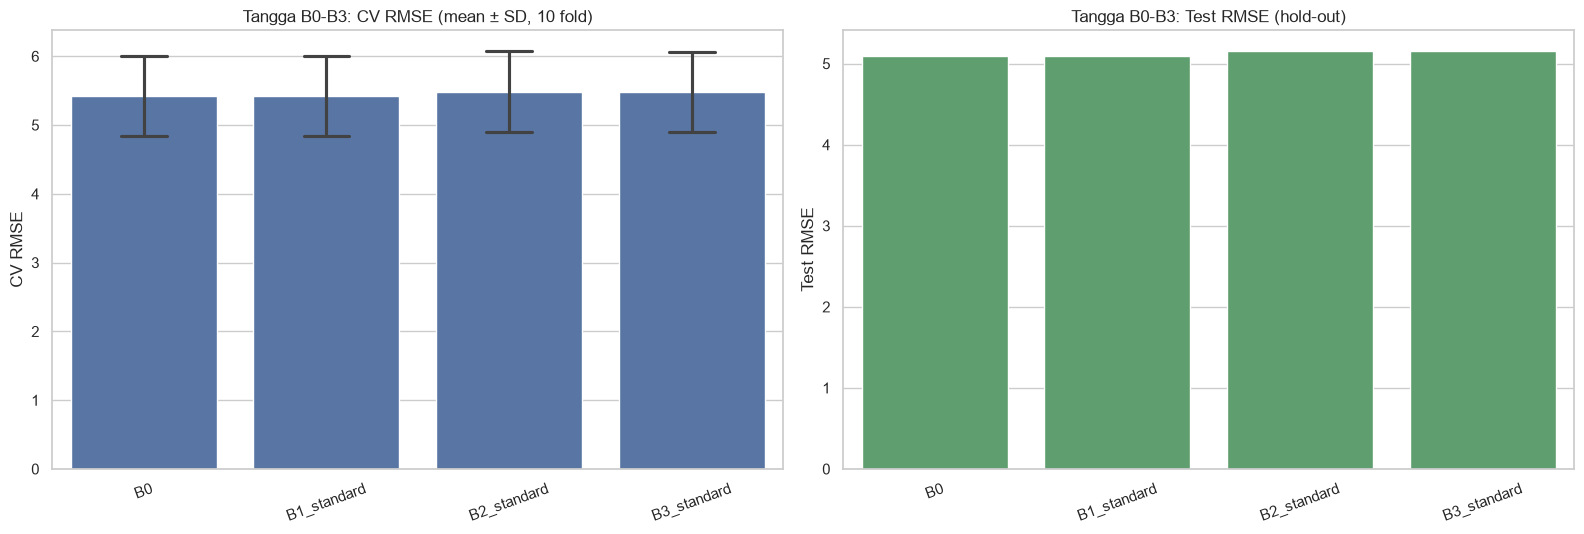

In [255]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / name, dpi=300, bbox_inches='tight')
    plt.show()


b_folds = folds_table[folds_table['Block'].isin(['B0', 'B1', 'B2', 'B3'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.barplot(data=b_folds, x='Experiment_ID', y='Validation_RMSE', errorbar='sd',
            capsize=0.25, ax=axes[0], color='#4C72B0')
axes[0].set_title('Tangga B0-B3: CV RMSE (mean ± SD, 10 fold)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel('CV RMSE')
sns.barplot(data=b_table, x='Experiment_ID', y='Test_RMSE', ax=axes[1], color='#55A868')
axes[1].set_title('Tangga B0-B3: Test RMSE (hold-out)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Test RMSE')
savefig('kontrol_block_B_tangga.png')

### 23.1 Visualisasi A1 — Feature Selection

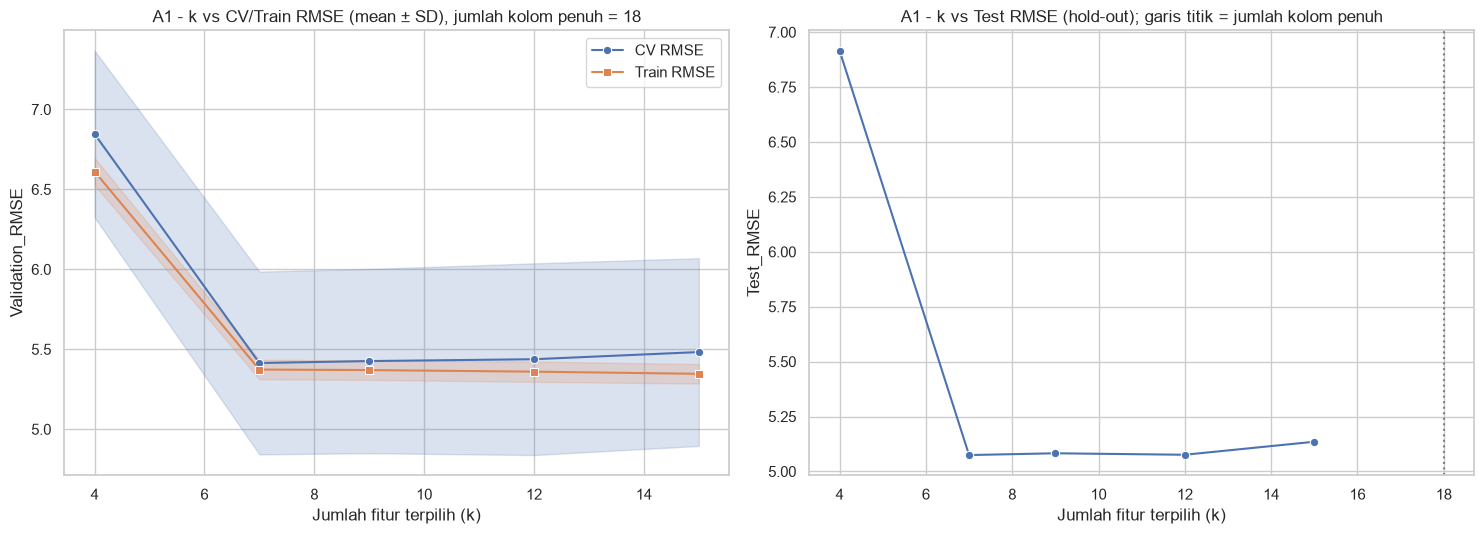

In [256]:
a1_folds = folds_table.query("Block == 'A1' and Experiment_ID != 'A1_kall'")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.lineplot(data=a1_folds, x='Feature_Selection_k', y='Validation_RMSE',
             marker='o', errorbar='sd', ax=axes[0], label='CV RMSE')
sns.lineplot(data=a1_folds, x='Feature_Selection_k', y='Fold_Training_RMSE',
             marker='s', errorbar='sd', ax=axes[0], label='Train RMSE')
axes[0].set_title(f'A1 - k vs CV/Train RMSE (mean ± SD), jumlah kolom penuh = {N_ENCODED}')
axes[0].set_xlabel('Jumlah fitur terpilih (k)')
axes[0].legend()
sns.lineplot(data=a1_table, x='Feature_Selection_k', y='Test_RMSE', marker='o', ax=axes[1])
axes[1].axvline(N_ENCODED, linestyle=':', color='gray')
axes[1].set_title('A1 - k vs Test RMSE (hold-out); garis titik = jumlah kolom penuh')
axes[1].set_xlabel('Jumlah fitur terpilih (k)')
savefig('kontrol_a1_feature_selection.png')

### 23.2 Visualisasi A2 — PCA

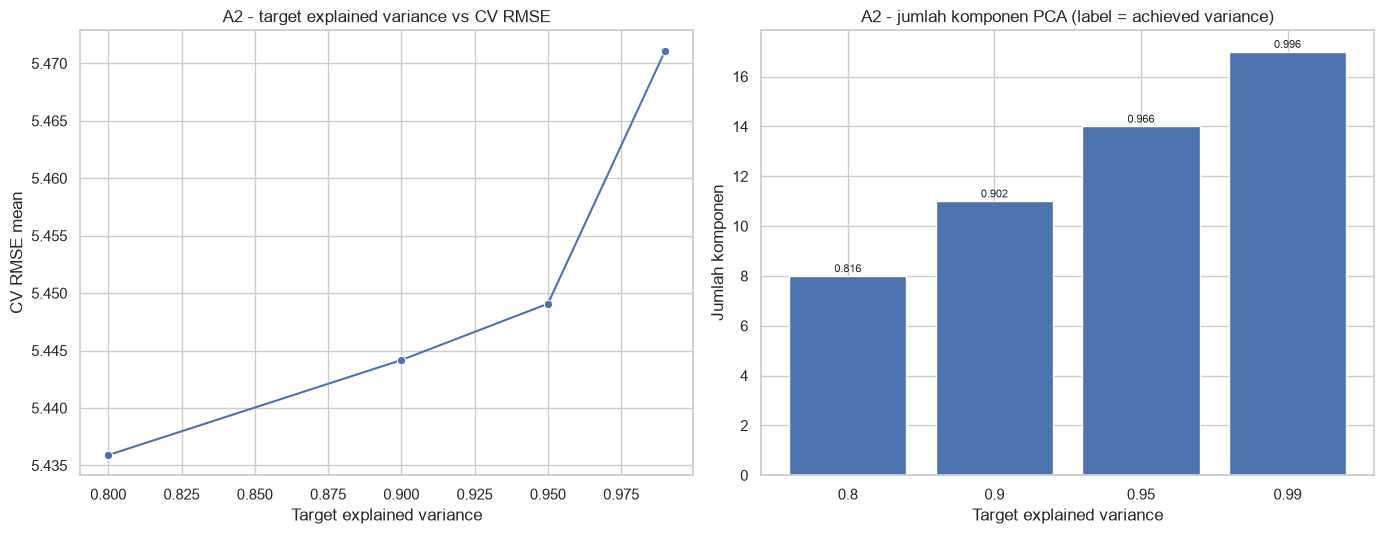

In [257]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.lineplot(data=a2_table, x='PCA_Target_Variance', y='Validation_RMSE_Mean',
             marker='o', ax=axes[0])
axes[0].set_title('A2 - target explained variance vs CV RMSE')
axes[0].set_xlabel('Target explained variance')
axes[0].set_ylabel('CV RMSE mean')
axes[1].bar(a2_table['PCA_Target_Variance'].astype(str), a2_table['PCA_Components'],
            color='#4C72B0')
for x, ev in enumerate(a2_table['Explained_Variance']):
    axes[1].text(x, a2_table['PCA_Components'].iloc[x] + 0.15, f'{ev:.3f}', ha='center', fontsize=8)
axes[1].set_title('A2 - jumlah komponen PCA (label = achieved variance)')
axes[1].set_xlabel('Target explained variance')
axes[1].set_ylabel('Jumlah komponen')
savefig('kontrol_a2_pca.png')

### 23.3 Visualisasi A3 — Sensitivitas Alpha dan Sparsitas

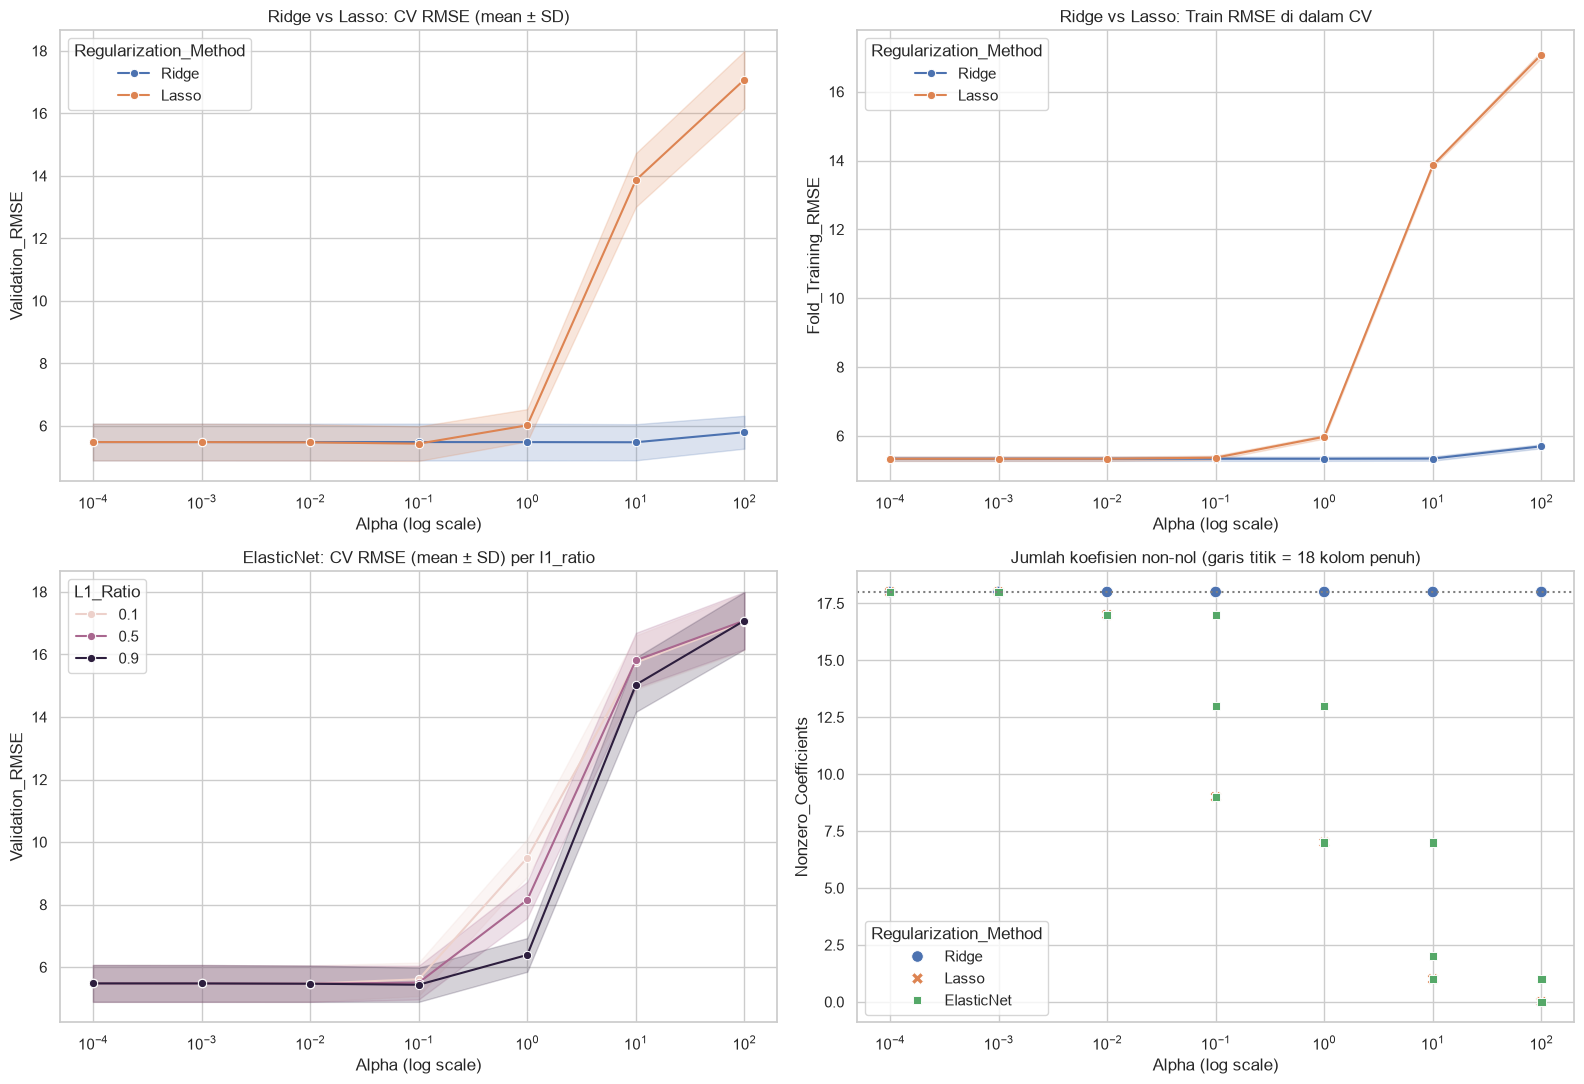

In [258]:
a3_folds = folds_table[folds_table['Block'] == 'A3']
ridge_lasso_folds = a3_folds[a3_folds['Regularization_Method'].isin(['Ridge', 'Lasso'])]
en_folds = a3_folds[a3_folds['Regularization_Method'] == 'ElasticNet']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.lineplot(data=ridge_lasso_folds, x='Alpha', y='Validation_RMSE',
             hue='Regularization_Method', marker='o', errorbar='sd', ax=axes[0, 0])
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('Ridge vs Lasso: CV RMSE (mean ± SD)')
axes[0, 0].set_xlabel('Alpha (log scale)')

sns.lineplot(data=ridge_lasso_folds, x='Alpha', y='Fold_Training_RMSE',
             hue='Regularization_Method', marker='o', errorbar='sd', ax=axes[0, 1])
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Ridge vs Lasso: Train RMSE di dalam CV')
axes[0, 1].set_xlabel('Alpha (log scale)')

sns.lineplot(data=en_folds, x='Alpha', y='Validation_RMSE', hue='L1_Ratio',
             marker='o', errorbar='sd', ax=axes[1, 0])
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('ElasticNet: CV RMSE (mean ± SD) per l1_ratio')
axes[1, 0].set_xlabel('Alpha (log scale)')

sns.scatterplot(data=a3_table, x='Alpha', y='Nonzero_Coefficients',
                hue='Regularization_Method', style='Regularization_Method', s=70, ax=axes[1, 1])
axes[1, 1].set_xscale('log')
axes[1, 1].axhline(N_ENCODED, linestyle=':', color='gray')
axes[1, 1].set_title(f'Jumlah koefisien non-nol (garis titik = {N_ENCODED} kolom penuh)')
axes[1, 1].set_xlabel('Alpha (log scale)')
savefig('kontrol_a3_regularization.png')

### 23.4 Dimensionalitas dan CV vs Test

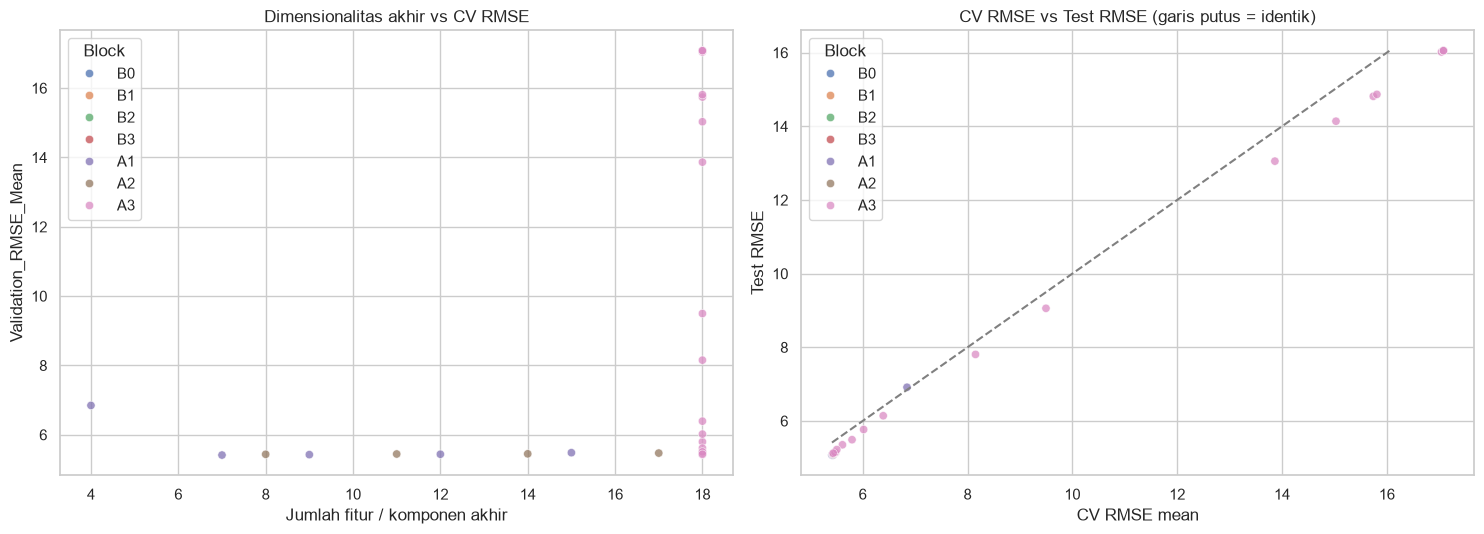

In [259]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=results_table, x='Final_Feature_Count', y='Validation_RMSE_Mean',
                hue='Block', alpha=0.75, ax=axes[0])
axes[0].set_title('Dimensionalitas akhir vs CV RMSE')
axes[0].set_xlabel('Jumlah fitur / komponen akhir')

sns.scatterplot(data=results_table, x='Validation_RMSE_Mean', y='Test_RMSE',
                hue='Block', alpha=0.75, ax=axes[1])
lims = [results_table['Validation_RMSE_Mean'].min(), results_table['Test_RMSE'].max()]
axes[1].plot(lims, lims, linestyle='--', color='gray')
axes[1].set_title('CV RMSE vs Test RMSE (garis putus = identik)')
axes[1].set_xlabel('CV RMSE mean')
axes[1].set_ylabel('Test RMSE')
savefig('kontrol_dimensionality_and_cv_vs_test.png')

## 24. Model Terpilih, Residual, dan Learning Curve

Konfigurasi dipilih berdasarkan **CV RMSE mean terkecil**, bukan berdasarkan test set.
Residual dan learning curve dipakai untuk diagnose asumsi model, bukan untuk optimasi.

In [260]:
selected_id = results_table.loc[results_table['Validation_RMSE_Mean'].idxmin(), 'Experiment_ID']
selected_spec = SPEC_BY_ID[selected_id]
selected_model = run_objects[selected_id]

sel_pred = selected_model.predict(x_block(X_test, selected_spec))
sel_metrics = evaluate_predictions(y_test, sel_pred)
residual = y_test.to_numpy() - sel_pred

print('Konfigurasi terpilih (aturan: argmin CV RMSE mean):')
display(pd.Series({
    'Experiment_ID': selected_id,
    'Block': selected_spec['block'],
    'Model': selected_spec['model'],
    'Scaler': SCALER_LABEL[selected_spec['scaler']],
    'Alpha': selected_spec['alpha'],
    'L1_Ratio': selected_spec['l1_ratio'],
    'Final_Feature_Count': run_records[selected_id]['Final_Feature_Count'],
    'CV_RMSE_Mean': run_records[selected_id]['Validation_RMSE_Mean'],
    'CV_RMSE_STD': run_records[selected_id]['Validation_RMSE_STD'],
    'Test_RMSE': sel_metrics['RMSE'],
    'Test_MAE': sel_metrics['MAE'],
    'Test_R2': sel_metrics['R2'],
}).to_frame('nilai'))

Konfigurasi terpilih (aturan: argmin CV RMSE mean):


,nilai
Experiment_ID,A1_k7
Block,A1
Model,LinearRegression
Scaler,StandardScaler
Alpha,NaN
L1_Ratio,NaN
Final_Feature_Count,7
CV_RMSE_Mean,5.414005
CV_RMSE_STD,0.571569
Test_RMSE,5.074502


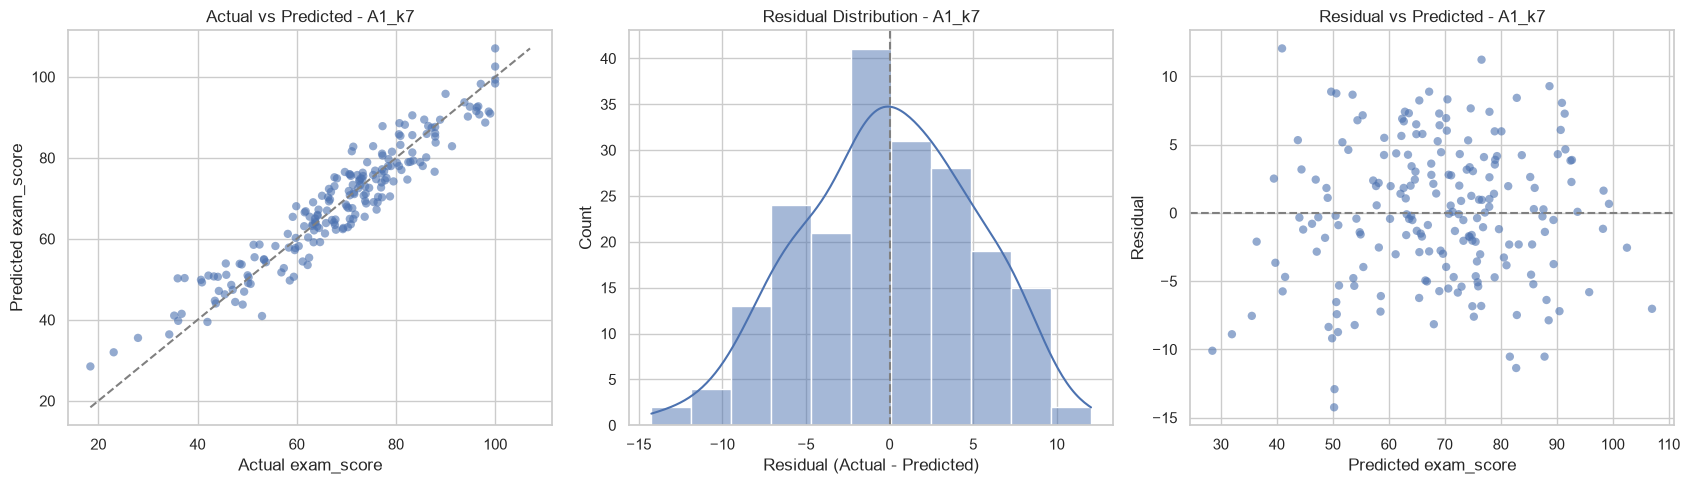

Mean residual : -0.0403  (dekat 0 berarti bias kecil)
SD residual   : 5.0871
MAE residual  : 4.1139


In [261]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(y_test, sel_pred, alpha=0.6, edgecolor='none')
lims = [min(y_test.min(), sel_pred.min()), max(y_test.max(), sel_pred.max())]
axes[0].plot(lims, lims, linestyle='--', color='gray')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title(f'Actual vs Predicted - {selected_id}')

sns.histplot(residual, kde=True, ax=axes[1], color='#4C72B0')
axes[1].axvline(0, linestyle='--', color='gray')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title(f'Residual Distribution - {selected_id}')

axes[2].scatter(sel_pred, residual, alpha=0.6, edgecolor='none')
axes[2].axhline(0, linestyle='--', color='gray')
axes[2].set_xlabel('Predicted exam_score')
axes[2].set_ylabel('Residual')
axes[2].set_title(f'Residual vs Predicted - {selected_id}')

savefig('kontrol_residual_selected.png')

print(f'Mean residual : {residual.mean():+.4f}  (dekat 0 berarti bias kecil)')
print(f'SD residual   : {residual.std(ddof=1):.4f}')
print(f'MAE residual  : {np.abs(residual).mean():.4f}')

## Penyimpanan Hasil

Keluaran ditulis ke `results/` dan `figures/` dengan prefiks `kontrol_` agar tidak bertabrakan
dengan keluaran notebook lain di folder yang sama.

In [262]:
files = {
    'results/kontrol_ablation_results.csv': results_table,
    'results/kontrol_cv_folds.csv': folds_table,
    'results/kontrol_cv_summary.csv': summary_all,
    'results/kontrol_delta_vs_b0.csv': delta_table,
    'results/kontrol_spec_grid.csv': grid_preview,
    'results/kontrol_collinearity_audit.csv': collinearity_audit,
    'results/kontrol_invariance_check.csv': invariance_table,
}

for rel_path, frame in files.items():
    p = Path(rel_path)
    p.parent.mkdir(exist_ok=True)
    frame.to_csv(p, index=False)
    print(f'{p}  ({len(frame)} baris)')

recap = (results_table.groupby('Block')
         .agg(N_Config=('Experiment_ID', 'count'),
              Best_CV_RMSE=('Validation_RMSE_Mean', 'min'),
              Best_Test_RMSE=('Test_RMSE', 'min'))
         .reset_index())
recap.to_csv('results/kontrol_recap_per_block.csv', index=False)
display(recap.round(4))

print()
print('Figure tersimpan di figures/:')
for p in sorted(FIGURES_DIR.glob('kontrol_*.png')):
    print(' ', p.name, f'({p.stat().st_size // 1024} KB)')

results\kontrol_ablation_results.csv  (49 baris)
results\kontrol_cv_folds.csv  (490 baris)
results\kontrol_cv_summary.csv  (49 baris)
results\kontrol_delta_vs_b0.csv  (49 baris)
results\kontrol_spec_grid.csv  (49 baris)
results\kontrol_collinearity_audit.csv  (2 baris)
results\kontrol_invariance_check.csv  (1 baris)


,Block,N_Config,Best_CV_RMSE,Best_Test_RMSE
0,A1,6,5.4140,5.0745
1,A2,4,5.4359,5.0971
2,A3,35,5.4311,5.1096
3,B0,1,5.4221,5.0913
4,B1,1,5.4221,5.0913
5,B2,1,5.4816,5.1510
6,B3,1,5.4803,5.1515



Figure tersimpan di figures/:
  kontrol_a1_feature_selection.png (290 KB)
  kontrol_a2_pca.png (191 KB)
  kontrol_a3_regularization.png (654 KB)
  kontrol_block_B_tangga.png (120 KB)
  kontrol_dimensionality_and_cv_vs_test.png (214 KB)
  kontrol_residual_selected.png (415 KB)
